# Pontos Notáveis do Triângulo

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio), [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (bissetriz de um ângulo), [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (elementos e classificação dos triângulos), [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (as propriedades do triângulo isósceles), [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (perpendicular por um ponto, projeção ortogonal, distância de ponto a reta e a mediatriz como lugar geométrico) e, de forma pontual, [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) (as diagonais do retângulo, que se cortam ao meio e são congruentes).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Traçar e definir as quatro "cevianas notáveis" do triângulo (mediana, bissetriz interna, mediatriz de um lado e altura) e reconhecer o ponto de encontro de cada trio.
- Justificar por que cada trio de linhas é **concorrente** (passa por um único ponto): baricentro, incentro, circuncentro e ortocentro.
- Usar as propriedades de cada ponto: a razão 2:1 no baricentro, a equidistância dos **lados** no incentro e a equidistância dos **vértices** no circuncentro.
- Localizar cada ponto conforme a classificação do triângulo (dentro, sobre o triângulo ou fora) e reconhecer a reta de Euler.

**Tempo estimado:** 75 a 90 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0410a_pontos_notaveis_do_triangulo.ipynb)

## Onde fica o "centro" de um triângulo?

Recorte um triângulo de papelão e tente equilibrá-lo na ponta de um lápis. Quem tenta descobre rápido que não serve qualquer ponto "mais ou menos no meio": apoiando perto do **meio de um lado**, a placa tomba; apoiando sobre a **bissetriz de um ângulo**, quase sempre tomba também. Existe **um** ponto certo.

Agora, três perguntas que parecem a mesma, mas não são:

1. **O lápis:** onde apoiar a placa para ela ficar equilibrada?
2. **O poste:** três casas querem dividir **um** poste de internet, e cada uma vai pagar pelo cabo até ele. Onde instalar o poste para que os três cabos tenham o **mesmo comprimento**?
3. **A fonte:** num jardim triangular, onde colocar a **maior fonte redonda possível**, sem invadir nenhum dos três muros?

Todas pedem "o centro do triângulo". Só que a palavra **centro** tem, num triângulo, **quatro** significados geométricos diferentes, e cada pergunta leva a um deles (o quarto vai aparecer de surpresa, na seção 4).

Antes da teoria, vamos experimentar. Execute a célula abaixo (ela carrega as ferramentas do notebook) e depois a do widget.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib import patheffects
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle, Polygon

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida, as mesmas de 0407a_perpendicularidade e 0409a_paralelogramos_e_casos_particulares
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def orientacao(O, P, Q) -> float:
    """Multiplicação cruzada com sinal (0408a): zero se O, P e Q são colineares, positiva se o
    caminho O → P → Q vira para a esquerda e negativa se vira para a direita."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")


def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r (que passa por `ponto_r`, com a inclinação dada):
    o pé da perpendicular a r traçada por P (0407a)."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r (0407a)."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


# Ferramentas novas deste notebook: medir e desenhar triângulos
# Uma cor fixa para cada ponto notável e para a família de linhas que o gera (vale no notebook inteiro)
CORES_NOTAVEIS = {"G": COR_PONTO, "I": COR_DESTAQUE, "O": COR_AVISO, "H": COR_EXTRA}
NOMES_NOTAVEIS = {"G": "baricentro", "I": "incentro", "O": "circuncentro", "H": "ortocentro"}
LINHAS_NOTAVEIS = {"G": "medianas", "I": "bissetrizes internas", "O": "mediatrizes", "H": "alturas"}
COR_TRIANGULO = NORD_TEXTO_SEC
COR_EULER = COR_ALERTA


def como_pontos(*pontos) -> list[np.ndarray]:
    """Converte pares (x, y) em arrays do numpy, para fazer contas com as coordenadas."""
    return [np.asarray(p, dtype=float) for p in pontos]


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def eh_triangulo(A, B, C) -> bool:
    """True se A, B e C não são colineares (multiplicação cruzada diferente de zero, 0401a)."""
    return abs(orientacao(A, B, C)) > 1e-9


def lados_do_triangulo(A, B, C) -> tuple[float, float, float]:
    """Medidas a = BC, b = CA e c = AB (cada letra minúscula é o lado oposto ao vértice de mesma letra, 0404a)."""
    return math.dist(B, C), math.dist(C, A), math.dist(A, B)


def angulos_do_triangulo(A, B, C) -> tuple[float, float, float]:
    """Medidas, em graus, dos ângulos internos Â, B̂ e Ĉ (com o transferidor digital)."""
    return medir_angulo(A, B, C), medir_angulo(B, C, A), medir_angulo(C, A, B)


def classificar_por_angulos(A, B, C) -> str:
    """'acutângulo', 'retângulo' ou 'obtusângulo', olhando para o maior ângulo (0404a)."""
    maior = max(angulos_do_triangulo(A, B, C))
    if math.isclose(maior, 90, abs_tol=1e-6):
        return "retângulo"
    return "obtusângulo" if maior > 90 else "acutângulo"


def posicao_no_triangulo(P, A, B, C) -> str:
    """Onde o ponto P está em relação ao triângulo ABC: 'dentro', 'sobre um vértice', 'sobre um lado'
    ou 'fora'. Usa o sinal da multiplicação cruzada (0408a): P está dentro quando fica, em relação a
    cada lado, do mesmo lado que o vértice oposto."""
    if any(math.dist(P, V) < 1e-6 for V in (A, B, C)):
        return "sobre um vértice"
    sentido = 1 if orientacao(A, B, C) > 0 else -1
    # distância com sinal de P a cada lado: positiva do lado de dentro, negativa do lado de fora
    distancias = [sentido * orientacao(X, Y, P) / math.dist(X, Y) for X, Y in ((A, B), (B, C), (C, A))]
    if any(d < -1e-6 for d in distancias):
        return "fora"
    if any(abs(d) <= 1e-6 for d in distancias):
        return "sobre um lado"
    return "dentro"


def distancias_aos_lados(P, A, B, C) -> tuple[float, float, float]:
    """Distâncias de P às retas BC, CA e AB, nessa ordem (distância de ponto a reta, 0407a)."""
    return tuple(distancia_ponto_reta(P, X, direcao_de(X, Y)) for X, Y in ((B, C), (C, A), (A, B)))


def esta_no_segmento(X, P, Q) -> bool:
    """True se o ponto X, que já sabemos estar na reta PQ, fica entre P e Q (inclusive nas pontas)."""
    X, P, Q = (np.asarray(p, dtype=float) for p in (X, P, Q))
    t = np.dot(X - P, Q - P) / np.dot(Q - P, Q - P)
    return -1e-9 <= t <= 1 + 1e-9


def desenhar_triangulo(ax, A, B, C, cor: str = COR_TRIANGULO, largura: float = 2.5, preencher: bool = True,
                       nomes: str = "ABC", distancia: float = 0.4) -> None:
    """Desenha o triângulo ABC (lados e interior levemente pintado) e escreve os nomes dos vértices
    do lado de fora da figura."""
    if preencher:
        ax.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_SECUNDARIA, alpha=0.12, edgecolor="none"))
    for P, Q in ((A, B), (B, C), (C, A)):
        ax.plot(*zip(P, Q), color=cor, lw=largura, solid_capstyle="round", zorder=3)
    centro = (np.asarray(A) + np.asarray(B) + np.asarray(C)) / 3
    for V, nome in zip((A, B, C), nomes):
        V = np.asarray(V, dtype=float)
        ax.plot(*V, "o", color=NORD_TEXTO, markersize=6, zorder=6)
        afastar = V - centro
        afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
        ax.text(*(V + distancia * afastar), nome, color=NORD_TEXTO, fontsize=13, fontweight="bold",
                ha="center", va="center", zorder=7)


def rotular_fora(ax, P, texto: str, centro, cor: str = NORD_TEXTO, distancia: float = 0.35,
                 tamanho: int = 12) -> None:
    """Escreve `texto` perto do ponto P, afastado do `centro` (para não ficar em cima da figura)."""
    P = np.asarray(P, dtype=float)
    afastar = P - np.asarray(centro, dtype=float)
    afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
    ax.text(*(P + distancia * afastar), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def desenhar_reta(ax, P, Q, cor: str, estilo: str = "--", largura: float = 1.5, alpha: float = 0.9) -> None:
    """Desenha a reta inteira que passa por P e por Q (até a borda do gráfico)."""
    ax.axline(tuple(np.asarray(P, dtype=float)), tuple(np.asarray(Q, dtype=float)), color=cor,
              linestyle=estilo, lw=largura, alpha=alpha, zorder=2)


def desenhar_circunferencia(ax, centro, raio: float, cor: str, estilo: str = "-", largura: float = 2.0) -> None:
    """Desenha a circunferência de centro e raio dados (só a linha, sem pintar o interior)."""
    ax.add_patch(Circle(tuple(np.asarray(centro, dtype=float)), raio, fill=False, edgecolor=cor, lw=largura,
                        linestyle=estilo, zorder=3))


DESLOCAMENTO_NOTAVEL = {"G": (0.15, 0.15), "I": (-0.5, 0.15), "O": (0.15, -0.55), "H": (-0.5, -0.55)}


def marcar_notavel(ax, P, letra: str, deslocamento=None, tamanho: int = 11) -> None:
    """Marca um ponto notável com a cor da sua família (G, I, O ou H) e escreve a letra ao lado."""
    cor = CORES_NOTAVEIS[letra]
    dx, dy = DESLOCAMENTO_NOTAVEL[letra] if deslocamento is None else deslocamento
    ax.plot(*P, "o", color=cor, markersize=tamanho, markeredgecolor=NORD_FUNDO, markeredgewidth=1.5, zorder=8)
    ax.text(P[0] + dx, P[1] + dy, letra, color=cor, fontsize=14, fontweight="bold", zorder=9,
            path_effects=[patheffects.withStroke(linewidth=3, foreground=NORD_FUNDO)])


def avisar_colineares(ax, ax_lista, A, B, C) -> None:
    """O que os widgets mostram quando os três vértices ficam alinhados (não há triângulo)."""
    pontos = sorted([tuple(A), tuple(B), tuple(C)])
    ax.plot(*zip(*pontos), color=COR_ALERTA, lw=3)
    for V, nome in zip((A, B, C), "ABC"):
        desenhar_ponto(ax, V, nome, cor=COR_ALERTA)
    ax.set_title("A, B e C estão alinhados: não formam um triângulo!", color=COR_ALERTA, fontsize=13)
    escrever_checklist(ax_lista, [], "Mova um dos vértices para fora da reta")


def painel_de_vertices(funcao, A, B, C, minimo: float = -1.0, maximo: float = 9.0, passo: float = 0.25) -> None:
    """Widget com seis sliders (x e y de cada vértice) que redesenha `funcao(A, B, C)` a cada mudança."""
    sliders = {}
    colunas = []
    for nome, ponto in zip("ABC", (A, B, C)):
        for eixo, valor in zip("xy", ponto):
            sliders[f"{eixo}{nome}"] = widgets.FloatSlider(value=float(valor), min=minimo, max=maximo, step=passo,
                                                           description=f"{eixo} de {nome}:")
        colunas.append(widgets.VBox([sliders[f"x{nome}"], sliders[f"y{nome}"]]))

    def redesenhar(xA: float, yA: float, xB: float, yB: float, xC: float, yC: float) -> None:
        funcao(np.array([xA, yA]), np.array([xB, yB]), np.array([xC, yC]))

    display(widgets.HBox(colunas), widgets.interactive_output(redesenhar, sliders))

🕹️ **Widget interativo:** o ponto branco $P$ é a ponta do lápis, que você move com os sliders `x de P` e `y de P`. À direita, três **medidores**:

- **distâncias aos vértices** (em amarelo): os comprimentos $PA$, $PB$ e $PC$ dos três cabos do poste;
- **distâncias aos lados** (em verde): a distância de $P$ a cada um dos três muros (medida na perpendicular, como em [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb));
- **tombo da placa** (em azul): o programa "pica" a placa em dezenas de milhares de pedacinhos de mesmo peso e soma o puxão de cada um em relação ao apoio $P$ (o braço de alavanca da física). Se os puxões se cancelam, a placa fica parada; senão, a seta mostra para que lado ela cai.

Desafio: tente **zerar** cada medidor (deixar as três barras do mesmo tamanho, ou o tombo em zero). Os três zeram no mesmo lugar?

In [ ]:
# O triângulo de papelão do gancho e a placa "picada" em pedacinhos de mesmo peso
A_g, B_g, C_g = como_pontos((0, 0), (9, 0), (2, 6))
grade_x, grade_y = np.meshgrid(np.linspace(0, 9, 451), np.linspace(0, 6, 301))
grade = np.column_stack([grade_x.ravel(), grade_y.ravel()])
na_placa = np.ones(len(grade), dtype=bool)
for X, Y in ((A_g, B_g), (B_g, C_g), (C_g, A_g)):  # do lado de dentro de cada lado (0408a)
    na_placa &= (Y[0] - X[0]) * (grade[:, 1] - X[1]) - (Y[1] - X[1]) * (grade[:, 0] - X[0]) >= 0
pedacinhos = grade[na_placa]


def medidor(ax, nomes, valores, titulo: str, cor: str, limite: float) -> None:
    """Barras horizontais com as medidas; o título fica verde quando o medidor "zera"."""
    estilizar_eixo(ax)
    ax.barh(nomes, valores, color=cor, height=0.6)
    for k, valor in enumerate(valores):
        ax.text(valor + 0.1, k, f"{valor:.2f}", color=NORD_TEXTO, va="center", fontsize=10)
    ax.set_xlim(0, limite)
    ax.invert_yaxis()
    ax.set_title(titulo, color=COR_DESTAQUE if "zerou" in titulo else NORD_TEXTO, fontsize=11, loc="left")


def explorar_centro(x: float, y: float) -> None:
    P = np.array([x, y])
    aos_vertices = [math.dist(P, V) for V in (A_g, B_g, C_g)]
    aos_lados = list(distancias_aos_lados(P, A_g, B_g, C_g))
    tombo = pedacinhos.mean(axis=0) - P  # média dos braços de alavanca de todos os pedacinhos
    fig = plt.figure(figsize=(15, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    gs = fig.add_gridspec(3, 2, width_ratios=[1.35, 1], hspace=0.7)
    ax = fig.add_subplot(gs[:, 0])
    preparar_eixo(ax, [A_g, B_g, C_g], margem=0.7)
    desenhar_triangulo(ax, A_g, B_g, C_g)
    for V in (A_g, B_g, C_g):
        ax.plot(*zip(P, V), color=COR_AVISO, lw=1.2, linestyle=":")
    for X, Y in ((B_g, C_g), (C_g, A_g), (A_g, B_g)):
        ax.plot(*zip(P, projecao_ortogonal(P, X, direcao_de(X, Y))), color=COR_DESTAQUE, lw=1.2, linestyle="--")
    if np.linalg.norm(tombo) > 0.05:
        ax.annotate("", xy=P + tombo, xytext=P,
                    arrowprops={"arrowstyle": "-|>", "color": COR_PONTO, "lw": 2.5, "mutation_scale": 20})
    ax.plot(*P, "*", color=NORD_TEXTO, markersize=18, markeredgecolor=NORD_FUNDO, zorder=9)
    ax.text(P[0] + 0.2, P[1] + 0.2, "P", color=NORD_TEXTO, fontsize=14, fontweight="bold", zorder=9)
    ax.set_title(f"Ponta do lápis em P = ({x:.1f}, {y:.1f}), {posicao_no_triangulo(P, A_g, B_g, C_g)} do triângulo",
                 color=NORD_TEXTO, fontsize=13)

    diferenca_v = max(aos_vertices) - min(aos_vertices)
    diferenca_l = max(aos_lados) - min(aos_lados)
    medidor(fig.add_subplot(gs[0, 1]), ["PA", "PB", "PC"], aos_vertices,
            f"aos vértices: diferença = {diferenca_v:.2f}" + ("  ✓ zerou!" if diferenca_v < 0.1 else ""), COR_AVISO, 10)
    medidor(fig.add_subplot(gs[1, 1]), ["a BC", "a CA", "a AB"], aos_lados,
            f"aos lados: diferença = {diferenca_l:.2f}" + ("  ✓ zerou!" if diferenca_l < 0.1 else ""), COR_DESTAQUE, 10)
    medidor(fig.add_subplot(gs[2, 1]), ["tombo"], [float(np.linalg.norm(tombo))],
            f"tombo da placa = {np.linalg.norm(tombo):.2f}" + ("  ✓ zerou!" if np.linalg.norm(tombo) < 0.1 else ""),
            COR_PONTO, 6)
    plt.show()


widgets.interact(
    explorar_centro,
    x=widgets.FloatSlider(value=5.0, min=0, max=9, step=0.1, description="x de P:"),
    y=widgets.FloatSlider(value=2.5, min=0, max=6, step=0.1, description="y de P:"),
);

interactive(children=(FloatSlider(value=5.0, description='x de P:', max=9.0), FloatSlider(value=2.5, descripti…

Se você caçou bem, encontrou **três pontos diferentes**, todos dentro do triângulo e próximos uns dos outros:

- o ponto que **zera o tombo** (perto de $(3{,}7;\ 2{,}0)$) é o ponto de equilíbrio do lápis;
- o ponto que **iguala as distâncias aos vértices** (perto de $(4{,}5;\ 1{,}8)$) é o lugar do poste;
- o ponto que **iguala as distâncias aos lados** (perto de $(3{,}1;\ 2{,}2)$) é o centro da maior fonte.

Cada um deles é o ponto de encontro de uma família de três linhas "especiais" do triângulo, e o notebook segue essa ordem: o **baricentro** e as medianas (seção 1), o **incentro** e as bissetrizes (seção 2), o **circuncentro** e as mediatrizes (seção 3) e o **ortocentro** e as alturas (seção 4, o "centro" que não tinha medidor). Na seção 5, os quatro aparecem juntos, com uma surpresa: três deles vivem sempre **na mesma reta**.

📎 **Conexão:** este é um notebook de **síntese**. Quase nenhuma ferramenta é nova; o que é novo é aplicá-las, todas, ao mesmo triângulo:

| Ferramenta | De onde vem | Onde volta aqui |
|---|---|---|
| ponto médio, $M = \left(\frac{x_A + x_B}{2}, \frac{y_A + y_B}{2}\right)$ | [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) | medianas (seção 1) e mediatrizes (seção 3) |
| bissetriz de um ângulo | [`0403a_angulos.ipynb`](0403a_angulos.ipynb) | bissetrizes internas (seção 2) |
| lados opostos aos vértices ($a = BC$, $b = CA$, $c = AB$), classificação por ângulos | [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) | todas as seções; posição de $O$ e $H$ (seções 3 e 4) |
| mediana, bissetriz e altura coincidindo no isósceles | [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) | casos especiais (seção 5) |
| perpendicular por um ponto, projeção ortogonal, distância de ponto a reta, mediatriz como lugar geométrico | [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) | incentro (seção 2), circuncentro (seção 3) e ortocentro (seção 4) |
| diagonais do losango (bissetrizes) e do retângulo (congruentes, cortando-se ao meio) | [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) | o cálculo da bissetriz (seção 2) e o triângulo retângulo (seção 3) |

Para que você associe cada linha ao seu ponto só de bater o olho, as cores são **fixas** no notebook inteiro: <span style="color:#88C0D0">**medianas e G em azul**</span>, <span style="color:#A3BE8C">**bissetrizes e I em verde**</span>, <span style="color:#EBCB8B">**mediatrizes e O em amarelo**</span> e <span style="color:#B48EAD">**alturas e H em lilás**</span> (as mesmas cores dos medidores do widget).

## 1. Baricentro: o ponto das medianas

📌 **Definição formal (mediana):** **mediana** de um triângulo é o segmento que liga um **vértice** ao **ponto médio do lado oposto**. Chamando de $M_a$, $M_b$ e $M_c$ os pontos médios dos lados $a = BC$, $b = CA$ e $c = AB$, as três medianas são $\overline{AM_a}$, $\overline{BM_b}$ e $\overline{CM_c}$.

O ponto médio vem direto de [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb): em coordenadas, é a média das coordenadas das extremidades.

📌 **Teorema (baricentro):** as três medianas de um triângulo se encontram em **um único ponto** $G$, chamado **baricentro**. Além disso, $G$ divide **cada** mediana na razão **2 : 1** a partir do vértice:

$$AG = 2 \cdot GM_a, \qquad BG = 2 \cdot GM_b, \qquad CG = 2 \cdot GM_c.$$

Em outras palavras, $G$ fica a $\frac{2}{3}$ do caminho, saindo do vértice: $AG = \frac{2}{3} AM_a$.

**Por que as três se encontram?** Com coordenadas, a demonstração cabe em uma linha. Pegue, na mediana $\overline{AM_a}$, o ponto $P$ que está a $\frac{2}{3}$ do caminho de $A$ até $M_a$ (as contas são feitas coordenada a coordenada, como o "quarto canto" $C = B + D - A$ de [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb)):

$$P = A + \frac{2}{3}\left(M_a - A\right) = A + \frac{2}{3}\left(\frac{B + C}{2} - A\right) = A + \frac{B + C}{3} - \frac{2A}{3} = \frac{A + B + C}{3}.$$

O resultado $\frac{A + B + C}{3}$ é **simétrico**: trocar os papéis de $A$, $B$ e $C$ não muda nada. Então, repetindo a conta nas medianas $\overline{BM_b}$ e $\overline{CM_c}$, o ponto a $\frac{2}{3}$ de cada uma é **o mesmo ponto**. Ele está nas três medianas (são concorrentes) e as divide na razão $2 : 1$, tudo de uma vez. ∎

$$\boxed{G = \left(\frac{x_A + x_B + x_C}{3},\ \frac{y_A + y_B + y_C}{3}\right)}$$

O baricentro é simplesmente a **média das coordenadas** dos três vértices, assim como o ponto médio é a média das duas extremidades.

**A representação numérica.** Vamos conferir, num triângulo dado por coordenadas, que $G$ está nas três medianas (multiplicação cruzada igual a zero, de [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb)) e que a razão é 2 nas três.

In [3]:
def baricentro(A, B, C) -> np.ndarray:
    """Baricentro G do triângulo ABC: a média das coordenadas dos três vértices."""
    return (np.asarray(A, dtype=float) + np.asarray(B, dtype=float) + np.asarray(C, dtype=float)) / 3



A, B, C = como_pontos((1, 6), (0, 0), (8, 1))
G = baricentro(A, B, C)
print(f"A = {A},  B = {B},  C = {C}")
print(f"G = ((1 + 0 + 8) / 3, (6 + 0 + 1) / 3) = ({G[0]:.4f}, {G[1]:.4f})\n")

linhas = []
for vertice, nome, P, Q, lado in ((A, "A", B, C, "a"), (B, "B", C, A, "b"), (C, "C", A, B, "c")):
    M = ponto_medio(P, Q)
    linhas.append({
        "mediana": f"{nome}M_{lado}",
        "ponto médio do lado oposto": f"M_{lado} = ({M[0]:g}, {M[1]:g})",
        "G está nela?": "✅" if math.isclose(orientacao(vertice, M, G), 0, abs_tol=1e-9) else "❌",
        "vértice → G": f"{math.dist(vertice, G):.4f}",
        "G → ponto médio": f"{math.dist(G, M):.4f}",
        "razão": f"{math.dist(vertice, G) / math.dist(G, M):.4f}",
        "(vértice → G) ÷ mediana": f"{math.dist(vertice, G) / math.dist(vertice, M):.4f}",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

A = [1. 6.],  B = [0. 0.],  C = [8. 1.]
G = ((1 + 0 + 8) / 3, (6 + 0 + 1) / 3) = (3.0000, 2.3333)



mediana,ponto médio do lado oposto,G está nela?,vértice → G,G → ponto médio,razão,(vértice → G) ÷ mediana
AM_a,"M_a = (4, 0.5)",✅,4.1767,2.0883,2.0000,0.6667
BM_b,"M_b = (4.5, 3.5)",✅,3.8006,1.9003,2.0000,0.6667
CM_c,"M_c = (0.5, 3)",✅,5.1747,2.5874,2.0000,0.6667


E a representação gráfica: as três medianas em azul, com os tracinhos marcando as metades congruentes de cada lado (o ponto médio divide o lado ao meio) e o baricentro $G$ no cruzamento.

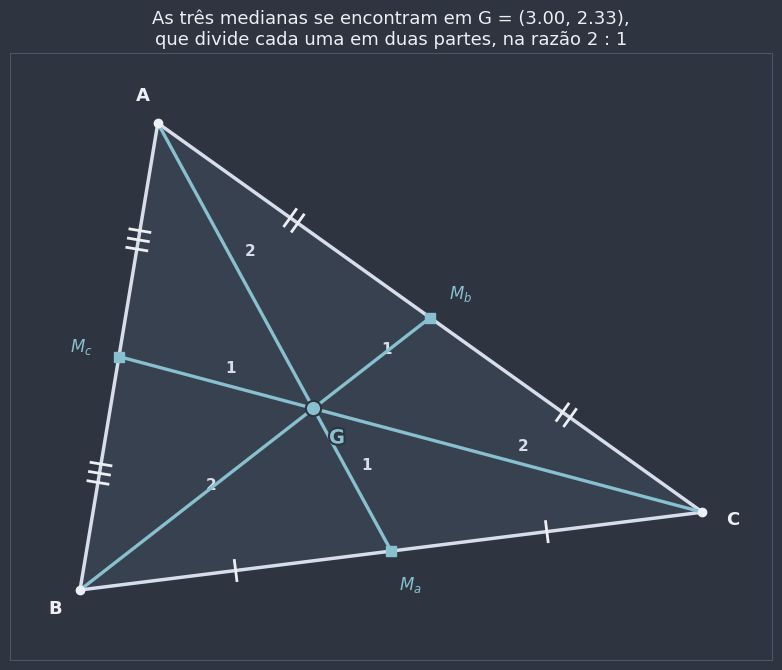

In [4]:
fig, ax = plt.subplots(figsize=(9, 6.8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A, B, C], margem=0.9)
desenhar_triangulo(ax, A, B, C)
for vertice, P, Q, lado, tracos in ((A, B, C, "a", 1), (B, C, A, "b", 2), (C, A, B, "c", 3)):
    M = ponto_medio(P, Q)
    ax.plot(*zip(vertice, M), color=CORES_NOTAVEIS["G"], lw=2.4, zorder=4)
    marcar_congruentes(ax, P, M, tracos, tamanho=0.13)
    marcar_congruentes(ax, M, Q, tracos, tamanho=0.13)
    ax.plot(*M, "s", color=CORES_NOTAVEIS["G"], markersize=7, zorder=6)
    rotular_fora(ax, M, rf"$M_{lado}$", G, cor=CORES_NOTAVEIS["G"], distancia=0.5)
    meio_vg = vertice + (G - vertice) / 2  # rótulo das duas partes de cada mediana
    ax.text(*(meio_vg + (0.12, 0.12)), "2", color=NORD_TEXTO_SEC, fontsize=11, fontweight="bold")
    meio_gm = G + (M - G) / 2
    ax.text(*(meio_gm + (0.12, 0.12)), "1", color=NORD_TEXTO_SEC, fontsize=11, fontweight="bold")
marcar_notavel(ax, G, "G", deslocamento=(0.2, -0.45))
ax.set_title(f"As três medianas se encontram em G = ({G[0]:.2f}, {G[1]:.2f}),\n"
             "que divide cada uma em duas partes, na razão 2 : 1", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** mova os três vértices com os sliders. As medianas e o baricentro são recalculados, e o painel da direita mostra a razão $\dfrac{\text{vértice} \to G}{G \to \text{ponto médio}}$ em cada mediana. Tente deixar o triângulo bem "achatado" ou com um ângulo bem obtuso: a razão muda? E o baricentro sai do triângulo?

In [5]:
def explorar_baricentro(A, B, C) -> None:
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.3, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1, -1), (9, 9)], margem=0.4)
    if not eh_triangulo(A, B, C):
        avisar_colineares(ax, ax_lista, A, B, C)
        plt.show()
        return
    desenhar_triangulo(ax, A, B, C)
    G = baricentro(A, B, C)
    itens = []
    for vertice, nome, P, Q in ((A, "A", B, C), (B, "B", C, A), (C, "C", A, B)):
        M = ponto_medio(P, Q)
        ax.plot(*zip(vertice, M), color=CORES_NOTAVEIS["G"], lw=2.4, zorder=4)
        ax.plot(*M, "s", color=CORES_NOTAVEIS["G"], markersize=7, zorder=6)
        razao = math.dist(vertice, G) / math.dist(G, M)
        itens.append((f"mediana de {nome}: {math.dist(vertice, G):.2f} ÷ {math.dist(G, M):.2f} = {razao:.3f}",
                      iguais(razao, 2)))
    posicao = posicao_no_triangulo(G, A, B, C)
    itens.append((f"G está {posicao} do triângulo", posicao == "dentro"))
    marcar_notavel(ax, G, "G")
    escrever_checklist(ax_lista, itens, "A razão 2 : 1 nas três medianas")
    ax.set_title(f"Triângulo {classificar_por_angulos(A, B, C)}: G = ({G[0]:.2f}, {G[1]:.2f})",
                 color=CORES_NOTAVEIS["G"], fontsize=13)
    plt.tight_layout()
    plt.show()


painel_de_vertices(explorar_baricentro, (1, 6), (0, 0), (8, 1))

Output()

🎯 **Aplicação prática — equilíbrio e centro de massa:** o baricentro é o **centro de gravidade** de uma placa triangular **homogênea** (de mesma espessura e mesmo material em toda parte): é o ponto do gancho, onde o lápis equilibra a placa. Engenheiros usam essa ideia o tempo todo: para pendurar um **móbile** sem que ele fique torto, para posicionar os apoios de uma **bandeja de três pés**, para fixar um **painel de sinalização** triangular num único poste sem que o vento e o peso o façam girar, e para calcular o centro de massa de peças de estruturas.

**Mas por que o ponto de equilíbrio é justamente o encontro das medianas?** Corte a placa em **tiras finíssimas paralelas** ao lado $\overline{BC}$. Cada tira é praticamente um segmento, e um segmento homogêneo se equilibra no seu **ponto médio**. Agora repare onde ficam esses pontos médios: a tira que está a uma fração $t$ do caminho entre $A$ e $\overline{BC}$ vai de $A + t(B - A)$ até $A + t(C - A)$, e o ponto médio dela é

$$\frac{\big(A + t(B - A)\big) + \big(A + t(C - A)\big)}{2} = A + t\left(\frac{B + C}{2} - A\right) = A + t\,(M_a - A),$$

um ponto da mediana $\overline{AM_a}$! Todas as tiras se equilibram sobre essa mediana, então a placa inteira se equilibra sobre ela (dá para apoiá-la numa régua posta ao longo de $\overline{AM_a}$). Cortando em tiras paralelas a $\overline{CA}$, o mesmo raciocínio mostra que a placa também se equilibra sobre $\overline{BM_b}$. O único ponto que está nas duas é $G$.

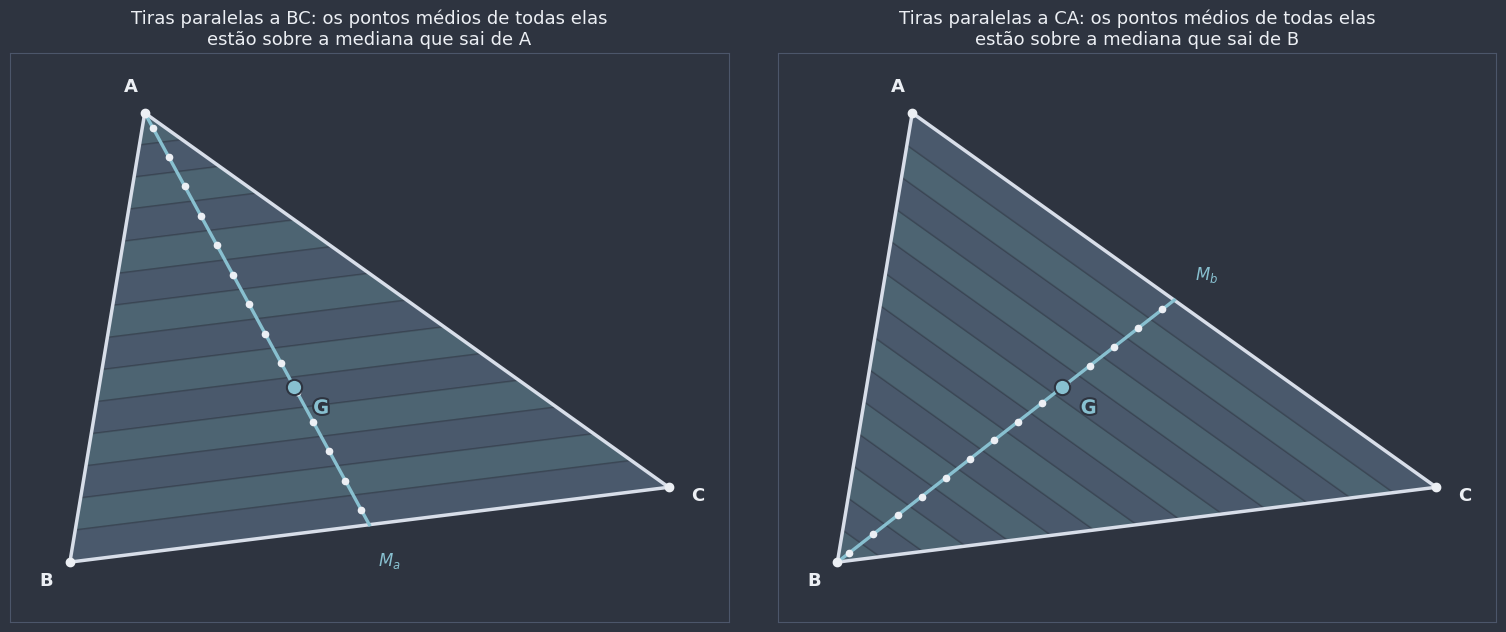

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(15.5, 6.2))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (vertice, P, Q, lado, texto) in zip(eixos, ((A, B, C, "a", "BC"), (B, C, A, "b", "CA"))):
    preparar_eixo(ax, [A, B, C], margem=0.8)
    numero_de_tiras = 14
    M = ponto_medio(P, Q)
    for k in range(numero_de_tiras):
        t0, t1 = k / numero_de_tiras, (k + 1) / numero_de_tiras
        tira = [vertice + t0 * (P - vertice), vertice + t1 * (P - vertice),
                vertice + t1 * (Q - vertice), vertice + t0 * (Q - vertice)]
        ax.add_patch(Polygon(tira, closed=True, facecolor=COR_SECUNDARIA if k % 2 else COR_PONTO, alpha=0.35,
                             edgecolor=NORD_FUNDO, lw=1.2))
        meio_da_tira = vertice + (t0 + t1) / 2 * (M - vertice)
        ax.plot(*meio_da_tira, "o", color=NORD_TEXTO, markersize=4.5, zorder=6)
    desenhar_triangulo(ax, A, B, C, preencher=False)
    ax.plot(*zip(vertice, M), color=CORES_NOTAVEIS["G"], lw=2.4, zorder=5)
    rotular_fora(ax, M, rf"$M_{lado}$", G, cor=CORES_NOTAVEIS["G"], distancia=0.55)
    marcar_notavel(ax, G, "G", deslocamento=(0.25, -0.35))
    ax.set_title(f"Tiras paralelas a {texto}: os pontos médios de todas elas\n"
                 f"estão sobre a mediana que sai de {'AB'[lado == 'b']}", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

💡 **Dica:** o baricentro está **sempre dentro** do triângulo, qualquer que seja a classificação (acutângulo, retângulo ou obtusângulo). A razão é simples: as medianas ligam um vértice a um ponto do lado oposto, então ficam inteiras dentro do triângulo, e $G$ é um ponto delas.

📎 **Conexão:** no triângulo **isósceles**, a mediana relativa à base coincide com a **altura** e com a **bissetriz** do ângulo do vértice (foi o "brinde" da demonstração por congruência em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)). Na seção 5 você vai ver o que isso faz com os quatro pontos notáveis. E o **comprimento** de uma mediana a partir dos lados do triângulo tem fórmula própria, que fica para 📌 Triângulos Quaisquer.

📖 **Leitura complementar:** [Centro de gravidade](https://pt.wikipedia.org/wiki/Centro_de_gravidade) (a interpretação física do baricentro) e [Mediana (geometria)](https://pt.wikipedia.org/wiki/Mediana_(geometria))

**Pergunta de checagem:** uma mediana de um triângulo mede 12 cm. Quanto mede o trecho dela entre o vértice e o baricentro? E entre o baricentro e o ponto médio do lado?

**Pergunta de checagem:** o triângulo tem vértices $A = (0, 0)$, $B = (6, 0)$ e $C = (3, 9)$. Sem desenhar, diga quais são as coordenadas do baricentro.

## 2. Incentro: o ponto das bissetrizes internas

Em [`0403a_angulos.ipynb`](0403a_angulos.ipynb), a **bissetriz** de um ângulo foi definida como a semirreta que o divide em dois ângulos congruentes. No triângulo, a **bissetriz interna** relativa ao vértice $A$ é o segmento dessa bissetriz que vai de $A$ até o lado oposto $\overline{BC}$. São três: uma por vértice.

Para entender o ponto de encontro delas, precisamos de uma ideia que já apareceu em [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb), com a mediatriz: a de **lugar geométrico**.

📌 **Definição formal (a bissetriz como lugar geométrico):** a bissetriz de um ângulo é o **lugar geométrico** dos pontos (do interior do ângulo) que são **equidistantes dos dois lados** do ângulo. Ou seja: um ponto está na bissetriz **se e somente se** está à mesma distância das duas semirretas que formam o ângulo.

É a "irmã" da mediatriz: a mediatriz junta os pontos equidistantes de **dois pontos**; a bissetriz junta os pontos equidistantes de **duas retas**. E a distância de um ponto a uma reta é medida na **perpendicular** ([`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb)). A ida da demonstração é uma congruência de triângulos ([`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)). Seja $P$ um ponto da bissetriz do ângulo de vértice $V$, e sejam $P_1$ e $P_2$ os pés das perpendiculares de $P$ aos dois lados:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $P\hat{V}P_1 \equiv P\hat{V}P_2$ | $\overrightarrow{VP}$ é a bissetriz |
| 2 | $V\hat{P_1}P = V\hat{P_2}P = 90^\circ$ | $P_1$ e $P_2$ são pés de perpendiculares |
| 3 | $\overline{VP}$ é comum | lado comum aos dois triângulos |
| 4 | $\triangle VPP_1 \equiv \triangle VPP_2$ | caso LAAo: passos 3, 1 e 2 (0405a) |
| 5 | $PP_1 = PP_2$ | lados correspondentes: $P$ é equidistante dos dois lados ∎ |

(A volta, "equidistante ⇒ está na bissetriz", sai do caso hipotenusa-cateto, com os mesmos dois triângulos retângulos.)

📌 **Teorema (incentro):** as três bissetrizes internas de um triângulo se encontram em **um único ponto** $I$, chamado **incentro**. Ele é **equidistante dos três lados**; por isso, é o centro da **circunferência inscrita** no triângulo (a que toca os três lados por dentro, sem atravessá-los), e a distância comum é o **raio** $r$ dessa circunferência.

**Por que as três se encontram?** O argumento é curto, e você vai reencontrá-lo na seção 3. Seja $I$ o ponto em que as bissetrizes de $\hat{A}$ e de $\hat{B}$ se cruzam.
- $I$ está na bissetriz de $\hat{A}$, então $\operatorname{dist}(I, AB) = \operatorname{dist}(I, AC)$.
- $I$ está na bissetriz de $\hat{B}$, então $\operatorname{dist}(I, AB) = \operatorname{dist}(I, BC)$.
- Juntando as duas: $\operatorname{dist}(I, AC) = \operatorname{dist}(I, BC)$. Pelo lugar geométrico, $I$ está também na bissetriz de $\hat{C}$. ∎

**No código**, como traçar uma bissetriz? Com o **truque do losango** de [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb): num losango, as diagonais são **bissetrizes** dos ângulos. Somando o vetor de tamanho 1 que aponta de $V$ para $P$ com o vetor de tamanho 1 que aponta de $V$ para $Q$, obtemos exatamente a diagonal do losango de lado 1 construído sobre o ângulo; a direção dessa soma é a direção da bissetriz. Depois, basta cruzar duas bissetrizes com a função `cruzamento`.

💡 **Dica (atalho):** também existe uma fórmula direta para o incentro, parecida com a do baricentro, só que é uma média **ponderada**, em que cada vértice "pesa" o tamanho do lado oposto a ele:

$$I = \frac{a \cdot A + b \cdot B + c \cdot C}{a + b + c}.$$

A justificativa usa o **teorema da bissetriz interna**, que ainda está por vir no módulo; por enquanto, vamos só conferir numericamente que ela dá o mesmo ponto que o cruzamento das bissetrizes.

In [7]:
def direcao_da_bissetriz(vertice, P, Q) -> float:
    """Inclinação, em graus, da bissetriz do ângulo de vértice `vertice` formado pelas semirretas que
    passam por P e por Q. É o truque do losango (0409a): somando os vetores de tamanho 1 que apontam
    para P e para Q, obtemos a diagonal de um losango, e a diagonal do losango é bissetriz."""
    V = np.asarray(vertice, dtype=float)
    u = (np.asarray(P, dtype=float) - V) / math.dist(V, P)
    w = (np.asarray(Q, dtype=float) - V) / math.dist(V, Q)
    return direcao_de(V, V + u + w)


def incentro(A, B, C) -> np.ndarray:
    """Incentro I do triângulo ABC: o cruzamento das bissetrizes internas de Â e de B̂."""
    return cruzamento(A, direcao_da_bissetriz(A, B, C), B, direcao_da_bissetriz(B, C, A))



def incentro_pela_formula(A, B, C) -> np.ndarray:
    """Atalho para o incentro: a média das coordenadas dos vértices ponderada pelos lados opostos,
    I = (a·A + b·B + c·C) / (a + b + c)."""
    a, b, c = lados_do_triangulo(A, B, C)
    A, B, C = como_pontos(A, B, C)
    return (a * A + b * B + c * C) / (a + b + c)



A, B, C = como_pontos((1, 6), (0, 0), (8, 1))  # o mesmo triângulo da seção 1
I = incentro(A, B, C)
a, b, c = lados_do_triangulo(A, B, C)
print(f"lados: a = BC = {a:.4f},  b = CA = {b:.4f},  c = AB = {c:.4f}")
print(f"I pelo cruzamento das bissetrizes de Â e B̂: ({I[0]:.4f}, {I[1]:.4f})")
print(f"I pela fórmula (a·A + b·B + c·C) / (a + b + c): ({incentro_pela_formula(A, B, C)[0]:.4f}, "
      f"{incentro_pela_formula(A, B, C)[1]:.4f})\n")

# A bissetriz de Ĉ passa por I? Então a semirreta CI divide Ĉ em duas metades iguais.
display(pd.DataFrame([
    {"vértice": nome, "ângulo inteiro": f"{medir_angulo(V, P, Q):.4f}°",
     "entre o 1º lado e VI": f"{medir_angulo(V, P, I):.4f}°", "entre VI e o 2º lado": f"{medir_angulo(V, I, Q):.4f}°",
     "VI é bissetriz?": "✅" if iguais(medir_angulo(V, P, I), medir_angulo(V, I, Q)) else "❌"}
    for V, nome, P, Q in ((A, "A", B, C), (B, "B", C, A), (C, "C", A, B))
]).style.hide(axis="index"))

# Distâncias de I aos três lados, medidas na perpendicular (0407a)
display(pd.DataFrame([
    {"lado": nome, "pé da perpendicular por I (ponto de tangência)": "({:.4f}, {:.4f})".format(
        *projecao_ortogonal(I, X, direcao_de(X, Y))), "distância de I ao lado": f"{distancia_ponto_reta(I, X, direcao_de(X, Y)):.6f}"}
    for X, Y, nome in ((B, C, "BC"), (C, A, "CA"), (A, B, "AB"))
]).style.hide(axis="index"))
r = distancia_ponto_reta(I, A, direcao_de(A, B))
print(f"raio da circunferência inscrita: r = {r:.4f}")

lados: a = BC = 8.0623,  b = CA = 8.6023,  c = AB = 6.0828
I pelo cruzamento das bissetrizes de Â e B̂: (2.4937, 2.3940)
I pela fórmula (a·A + b·B + c·C) / (a + b + c): (2.4937, 2.3940)



vértice,ângulo inteiro,entre o 1º lado e VI,entre VI e o 2º lado,VI é bissetriz?
A,63.9246°,31.9623°,31.9623°,✅
B,73.4127°,36.7063°,36.7063°,✅
C,42.6627°,21.3313°,21.3313°,✅


lado,pé da perpendicular por I (ponto de tangência),distância de I ao lado
BC,"(2.7499, 0.3437)",2.066175
CA,"(3.6946, 4.0753)",2.066175
AB,"(0.4556, 2.7336)",2.066175


raio da circunferência inscrita: r = 2.0662


E o desenho: as três bissetrizes internas em verde, o incentro $I$, os três pés das perpendiculares de $I$ aos lados (os pontos em que a circunferência inscrita **toca** os lados) e a própria circunferência inscrita, de raio $r$.

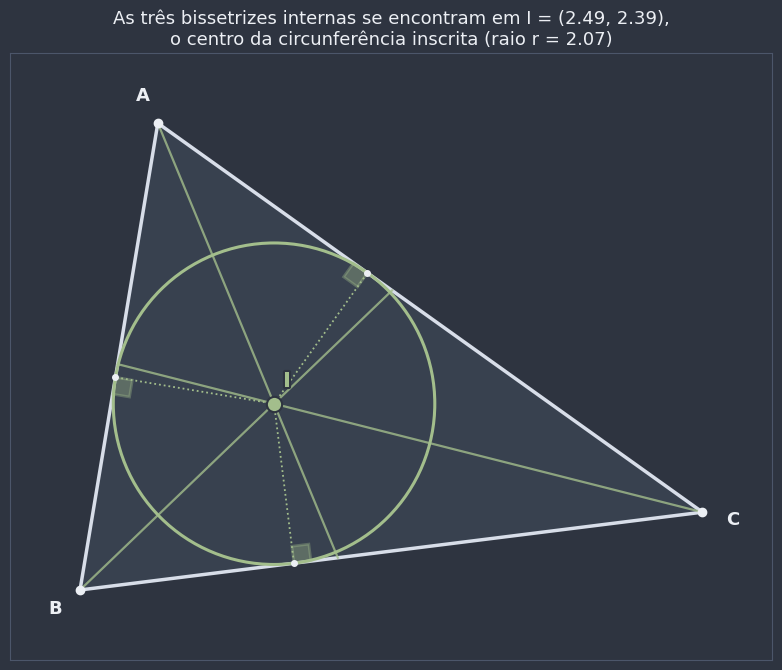

In [8]:
def pe_da_bissetriz(vertice, P, Q) -> np.ndarray:
    """Ponto em que a bissetriz interna que sai de `vertice` encontra o lado oposto PQ."""
    return cruzamento(vertice, direcao_da_bissetriz(vertice, P, Q), P, direcao_de(P, Q))


def desenhar_incentro(ax, A, B, C) -> tuple[np.ndarray, float]:
    """Bissetrizes internas, incentro, pontos de tangência e circunferência inscrita. Devolve (I, r)."""
    I = incentro(A, B, C)
    r = distancia_ponto_reta(I, A, direcao_de(A, B))
    desenhar_circunferencia(ax, I, r, CORES_NOTAVEIS["I"], largura=2.2)
    for vertice, P, Q in ((A, B, C), (B, C, A), (C, A, B)):
        ax.plot(*zip(vertice, pe_da_bissetriz(vertice, P, Q)), color=CORES_NOTAVEIS["I"], lw=1.6, alpha=0.8, zorder=4)
        T = projecao_ortogonal(I, P, direcao_de(P, Q))  # ponto de tangência no lado PQ
        ax.plot(*zip(I, T), color=CORES_NOTAVEIS["I"], lw=1.3, linestyle=":", zorder=4)
        marcar_angulo_reto(ax, T, Q if math.dist(T, Q) > 1e-9 else P, I, tamanho=0.22, cor=CORES_NOTAVEIS["I"])
        ax.plot(*T, "o", color=NORD_TEXTO, markersize=4, zorder=6)
    marcar_notavel(ax, I, "I", deslocamento=(0.12, 0.22))
    return I, r


fig, ax = plt.subplots(figsize=(9, 6.8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A, B, C], margem=0.9)
desenhar_triangulo(ax, A, B, C)
I, r = desenhar_incentro(ax, A, B, C)
ax.set_title(f"As três bissetrizes internas se encontram em I = ({I[0]:.2f}, {I[1]:.2f}),\n"
             f"o centro da circunferência inscrita (raio r = {r:.2f})", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** mova os vértices e acompanhe o incentro e a circunferência inscrita. O painel mostra as três distâncias de $I$ aos lados, que permanecem **iguais** (e iguais ao raio $r$) em qualquer triângulo, e confere a fórmula do atalho. A circunferência inscrita chega a sair do triângulo em algum momento?

In [ ]:
def explorar_incentro(A, B, C) -> None:
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.3, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1, -1), (9, 9)], margem=0.4)
    if not eh_triangulo(A, B, C):
        avisar_colineares(ax, ax_lista, A, B, C)
        plt.show()
        return
    desenhar_triangulo(ax, A, B, C)
    I, r = desenhar_incentro(ax, A, B, C)
    d_BC, d_CA, d_AB = distancias_aos_lados(I, A, B, C)
    posicao = posicao_no_triangulo(I, A, B, C)
    itens = [
        (f"distância de I a BC = {d_BC:.3f}", iguais(d_BC, r)),
        (f"distância de I a CA = {d_CA:.3f}", iguais(d_CA, r)),
        (f"distância de I a AB = {d_AB:.3f}", iguais(d_AB, r)),
        ("fórmula (a·A + b·B + c·C)/(a + b + c) confere", bool(np.allclose(I, incentro_pela_formula(A, B, C)))),
        (f"I está {posicao} do triângulo", posicao == "dentro"),
    ]
    escrever_checklist(ax_lista, itens, f"I equidistante dos lados: r = {r:.3f}")
    ax.set_title(f"Triângulo {classificar_por_angulos(A, B, C)}: I = ({I[0]:.2f}, {I[1]:.2f})",
                 color=CORES_NOTAVEIS["I"], fontsize=13)
    plt.tight_layout()
    plt.show()


painel_de_vertices(explorar_incentro, (1, 6), (0, 0), (8, 1))

Output()

🎯 **Aplicação prática — o maior círculo que cabe:** a terceira pergunta do gancho. Um círculo de centro $P$ cabe dentro do triângulo sem invadir nenhum lado só se o raio não passar da **menor** das três distâncias de $P$ aos lados. Então, o maior círculo possível com centro em $P$ tem raio $\min(d_{BC}, d_{CA}, d_{AB})$, e a pergunta vira: **qual ponto deixa esse mínimo o maior possível?** É o incentro, e o maior círculo é a circunferência inscrita. É a conta que se faz para posicionar uma **fonte** num jardim triangular, um **furo** ou um **rolamento** numa chapa de metal triangular, ou a maior **roda dentada** que cabe numa peça de um mecanismo.

O mapa abaixo pinta cada ponto do triângulo com o raio do maior círculo centrado nele (quanto mais claro, maior). O ponto mais claro de todos é o incentro. Para comparar, aparecem também os maiores círculos centrados no baricentro $G$ e num ponto qualquer $P$.

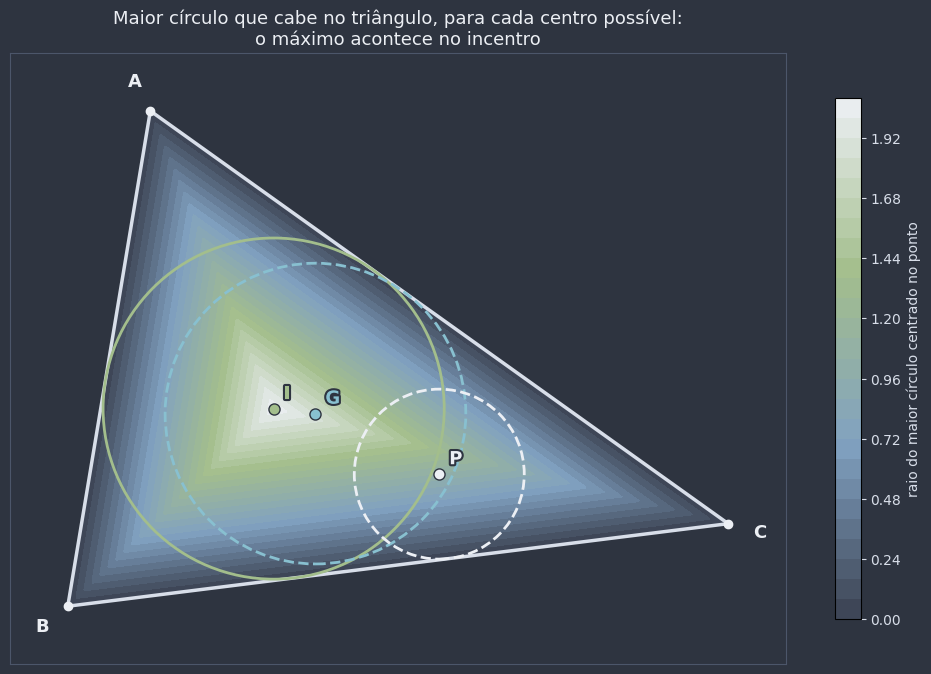

centro,"distâncias a BC, CA, AB",raio do maior círculo (a menor delas)
I (incentro),"2.066, 2.066, 2.066",2.066
G (baricentro),"1.943, 1.821, 2.576",1.821
P (um ponto qualquer),"1.029, 1.546, 4.176",1.029


In [10]:
xs = np.linspace(min(p[0] for p in (A, B, C)), max(p[0] for p in (A, B, C)), 500)
ys = np.linspace(min(p[1] for p in (A, B, C)), max(p[1] for p in (A, B, C)), 400)
X, Y = np.meshgrid(xs, ys)
sentido = 1 if orientacao(A, B, C) > 0 else -1
# distância com sinal de cada ponto da grade a cada lado (positiva do lado de dentro)
distancias = [sentido * ((Q[0] - P[0]) * (Y - P[1]) - (Q[1] - P[1]) * (X - P[0])) / math.dist(P, Q)
              for P, Q in ((A, B), (B, C), (C, A))]
maior_raio = np.minimum.reduce(distancias)
maior_raio[maior_raio < 0] = np.nan  # fora do triângulo

mapa_nord = LinearSegmentedColormap.from_list("nord_verde", [NORD_PAINEL, COR_SECUNDARIA, COR_DESTAQUE, NORD_TEXTO])
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A, B, C], margem=0.7)
imagem = ax.contourf(X, Y, maior_raio, levels=30, cmap=mapa_nord)
barra = fig.colorbar(imagem, ax=ax, shrink=0.8)
barra.set_label("raio do maior círculo centrado no ponto", color=NORD_TEXTO_SEC)
barra.ax.tick_params(colors=NORD_TEXTO_SEC)
desenhar_triangulo(ax, A, B, C, preencher=False)
G = baricentro(A, B, C)
P_qualquer = np.array([4.5, 1.6])
candidatos = {"I (incentro)": I, "G (baricentro)": G, "P (um ponto qualquer)": P_qualquer}
for nome, centro in candidatos.items():
    raio = min(distancias_aos_lados(centro, A, B, C))
    cor = CORES_NOTAVEIS["I"] if nome.startswith("I") else (CORES_NOTAVEIS["G"] if nome.startswith("G") else NORD_TEXTO)
    desenhar_circunferencia(ax, centro, raio, cor, estilo="-" if nome.startswith("I") else "--", largura=2)
    ax.plot(*centro, "o", color=cor, markersize=8, markeredgecolor=NORD_FUNDO, zorder=8)
    ax.text(centro[0] + 0.12, centro[1] + 0.12, nome[0], color=cor, fontsize=13, fontweight="bold", zorder=9,
            path_effects=[patheffects.withStroke(linewidth=3, foreground=NORD_FUNDO)])
ax.set_title("Maior círculo que cabe no triângulo, para cada centro possível:\no máximo acontece no incentro",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"centro": nome, "distâncias a BC, CA, AB": ", ".join(f"{d:.3f}" for d in distancias_aos_lados(c_, A, B, C)),
     "raio do maior círculo (a menor delas)": f"{min(distancias_aos_lados(c_, A, B, C)):.3f}"}
    for nome, c_ in candidatos.items()
]).style.hide(axis="index"))

💡 **Dica:** assim como o baricentro, o incentro está **sempre dentro** do triângulo: as bissetrizes internas saem de um vértice e terminam no lado oposto, ficando inteiras do lado de dentro.

⚠️ **Erro comum:** confundir **incentro** com **circuncentro** (seção 3). Os nomes são parecidos, mas as propriedades são "opostas": o incentro é equidistante dos **lados** (e vem das **bissetrizes**); o circuncentro é equidistante dos **vértices** (e vem das **mediatrizes**). Um truque para não esquecer:
- **In**centro ↔ circunferência **in**scrita (fica **dentro**, encostando nos lados);
- **Circun**centro ↔ circunferência **circun**scrita (fica **em volta**, passando pelos vértices).

📖 **Leitura complementar:** [Incentro](https://pt.wikipedia.org/wiki/Incentro) e [Bissetriz](https://pt.wikipedia.org/wiki/Bissetriz)

**Pergunta de checagem:** um ponto no interior de um triângulo está a 3 cm de dois dos lados. Em qual linha notável do triângulo ele está obrigatoriamente?

**Pergunta de checagem:** o incentro de um triângulo está a 2 cm do lado $\overline{AB}$. A que distância ele está dos outros dois lados? E qual é o diâmetro da circunferência inscrita?

## 3. Circuncentro: o ponto das mediatrizes

A **mediatriz** de um segmento foi o assunto final de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb): é a reta **perpendicular** ao segmento pelo seu **ponto médio**, e é também o **lugar geométrico** dos pontos **equidistantes das extremidades** do segmento. Um triângulo tem três lados, então tem três mediatrizes.

📌 **Teorema (circuncentro):** as mediatrizes dos três lados de um triângulo se encontram em **um único ponto** $O$, chamado **circuncentro**. Ele é **equidistante dos três vértices**; por isso, é o centro da **circunferência circunscrita** ao triângulo (a que passa pelos três vértices), e a distância comum é o **raio circunscrito** $R$:

$$OA = OB = OC = R.$$

**Por que as três se encontram?** É o mesmo argumento da seção 2, com "pontos" no lugar de "lados". Seja $O$ o ponto em que as mediatrizes de $\overline{AB}$ e de $\overline{BC}$ se cruzam (elas se cruzam mesmo: se fossem paralelas, $\overline{AB}$ e $\overline{BC}$, perpendiculares a elas, também seriam paralelas, e $A$, $B$, $C$ estariam alinhados).

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $OA = OB$ | $O$ está na mediatriz de $\overline{AB}$ (lugar geométrico, 0407a) |
| 2 | $OB = OC$ | $O$ está na mediatriz de $\overline{BC}$ |
| 3 | $OA = OC$ | passos 1 e 2 (propriedade transitiva) |
| 4 | $O$ está na mediatriz de $\overline{AC}$ | passo 3 e o lugar geométrico ("equidistante" ⇒ "sobre a mediatriz") ∎ |

⚠️ **Ponto de atenção:** ao contrário de $G$ e de $I$, o circuncentro **nem sempre fica dentro** do triângulo. Depende da classificação quanto aos ângulos ([`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb)):

| Triângulo | Onde fica o circuncentro $O$ |
|---|---|
| **acutângulo** | **dentro** do triângulo |
| **retângulo** | **no ponto médio da hipotenusa** (sobre o triângulo) |
| **obtusângulo** | **fora** do triângulo (do lado do maior lado) |

**O caso retângulo, demonstrado.** Seja $ABC$ retângulo em $A$. Complete-o com o "quarto canto" $D = B + C - A$ de [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb): o quadrilátero $ABDC$ é um paralelogramo com um ângulo reto, ou seja, um **retângulo**. Num retângulo, as diagonais $\overline{AD}$ e $\overline{BC}$ se **cortam ao meio** e são **congruentes**. Então o ponto médio $M$ da hipotenusa $\overline{BC}$ é também o ponto médio de $\overline{AD}$, e

$$MA = \frac{AD}{2} = \frac{BC}{2} = MB = MC.$$

$M$ é equidistante dos três vértices: é o circuncentro, e $R = \dfrac{\text{hipotenusa}}{2}$. ∎

**No código**, o circuncentro é o `cruzamento` de duas mediatrizes, cada uma descrita por um ponto (o ponto médio do lado) e uma inclinação (a do lado, girada de 90°). Vamos testar nos três tipos de triângulo.

In [11]:
def circuncentro(A, B, C) -> np.ndarray:
    """Circuncentro O do triângulo ABC: o cruzamento das mediatrizes de AB e de BC
    (cada mediatriz é a perpendicular ao lado pelo seu ponto médio, 0407a)."""
    return cruzamento(ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B)),
                      ponto_medio(B, C), inclinacao_da_perpendicular(direcao_de(B, C)))



TRIANGULOS_TIPOS = {
    "acutângulo": como_pontos((2, 5), (0, 0), (6, 0)),
    "retângulo em A": como_pontos((0, 0), (6, 0), (0, 4)),
    "obtusângulo em A": como_pontos((2, 1.5), (0, 0), (7, 0)),
}

linhas = []
for tipo, (A, B, C) in TRIANGULOS_TIPOS.items():
    O = circuncentro(A, B, C)
    linhas.append({
        "triângulo": tipo,
        "ângulos Â, B̂, Ĉ": ", ".join(f"{x:.1f}°" for x in angulos_do_triangulo(A, B, C)),
        "classificação": classificar_por_angulos(A, B, C),
        "O": f"({O[0]:.3f}, {O[1]:.3f})",
        "OA, OB, OC": ", ".join(f"{math.dist(O, V):.4f}" for V in (A, B, C)),
        "posição de O": posicao_no_triangulo(O, A, B, C),
        "O = ponto médio de BC?": "✅" if np.allclose(O, ponto_medio(B, C)) else "—",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

triângulo,"ângulos Â, B̂, Ĉ",classificação,O,"OA, OB, OC",posição de O,O = ponto médio de BC?
acutângulo,"60.5°, 68.2°, 51.3°",acutângulo,"(3.000, 1.700)","3.4482, 3.4482, 3.4482",dentro,—
retângulo em A,"90.0°, 33.7°, 56.3°",retângulo,"(3.000, 2.000)","3.6056, 3.6056, 3.6056",sobre um lado,✅
obtusângulo em A,"126.4°, 36.9°, 16.7°",obtusângulo,"(3.500, -2.583)","4.3501, 4.3501, 4.3501",fora,—


O desenho mostra as três mediatrizes (em amarelo, com o quadradinho do ângulo reto no ponto médio de cada lado), o circuncentro $O$ e a circunferência circunscrita passando pelos três vértices. No triângulo retângulo, aparece também o retângulo $ABDC$ da demonstração, tracejado.

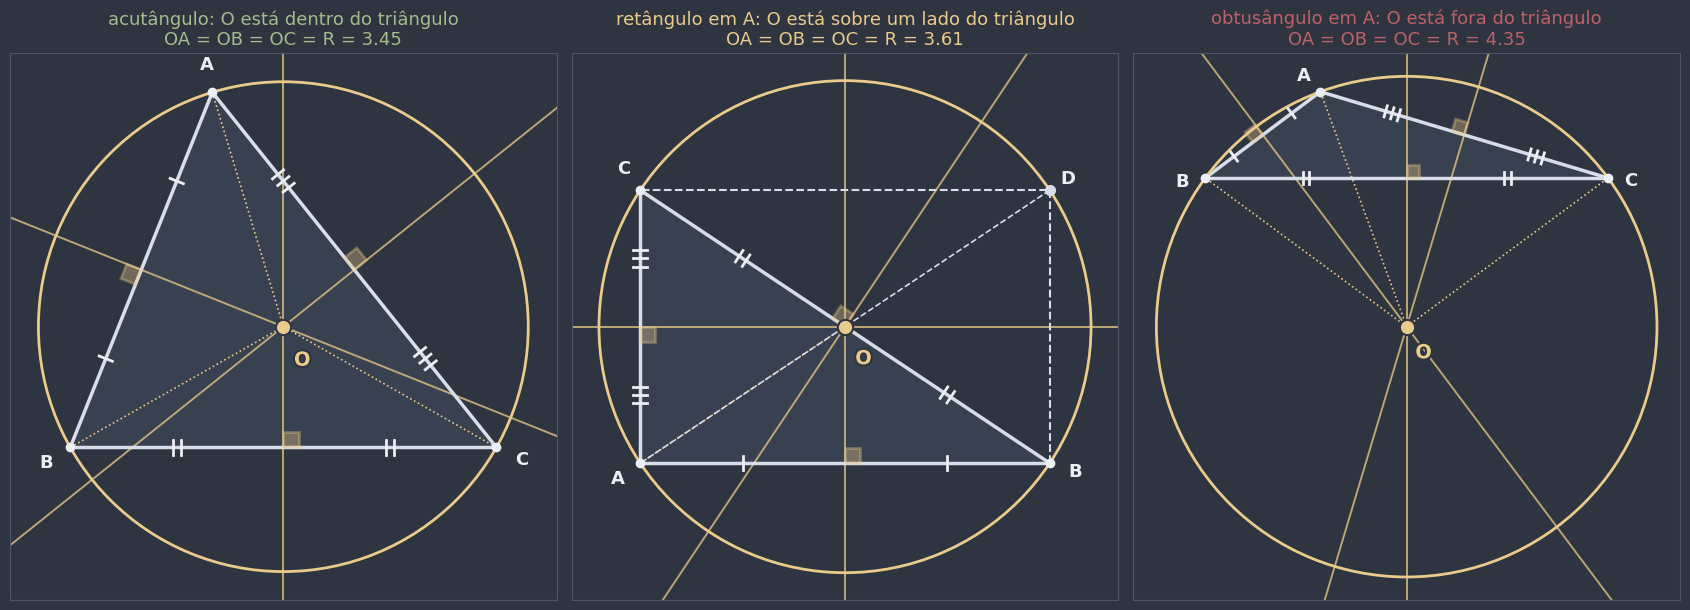

In [12]:
def desenhar_circuncentro(ax, A, B, C) -> tuple[np.ndarray, float]:
    """Mediatrizes, circuncentro, raios até os vértices e circunferência circunscrita. Devolve (O, R)."""
    O = circuncentro(A, B, C)
    R = math.dist(O, A)
    desenhar_circunferencia(ax, O, R, CORES_NOTAVEIS["O"], largura=2)
    for P, Q, tracos in ((A, B, 1), (B, C, 2), (C, A, 3)):
        M = ponto_medio(P, Q)
        normal = direcao(inclinacao_da_perpendicular(direcao_de(P, Q)))
        desenhar_reta(ax, M, M + normal, cor=CORES_NOTAVEIS["O"], estilo="-", largura=1.4, alpha=0.75)
        marcar_angulo_reto(ax, M, Q, M + normal, tamanho=0.22, cor=CORES_NOTAVEIS["O"])
        marcar_congruentes(ax, P, M, tracos, tamanho=0.1)
        marcar_congruentes(ax, M, Q, tracos, tamanho=0.1)
    for V in (A, B, C):
        ax.plot(*zip(O, V), color=CORES_NOTAVEIS["O"], lw=1.2, linestyle=":")
    marcar_notavel(ax, O, "O")
    return O, R


fig, eixos = plt.subplots(1, 3, figsize=(17, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (tipo, (A, B, C)) in zip(eixos, TRIANGULOS_TIPOS.items()):
    O = circuncentro(A, B, C)
    R = math.dist(O, A)
    preparar_eixo(ax, [A, B, C, O + (R, R), O - (R, R)], margem=0.4)
    desenhar_triangulo(ax, A, B, C)
    desenhar_circuncentro(ax, A, B, C)
    if tipo.startswith("retângulo"):
        D = B + C - A
        ax.plot(*zip(B, D, C), color=NORD_TEXTO_SEC, lw=1.5, linestyle="--")
        ax.plot(*zip(A, D), color=NORD_TEXTO_SEC, lw=1.2, linestyle="--")
        desenhar_ponto(ax, D, "D", cor=NORD_TEXTO_SEC, deslocamento=(0.15, 0.1))
    posicao = posicao_no_triangulo(O, A, B, C)
    cor = {"dentro": COR_DESTAQUE, "fora": COR_ALERTA}.get(posicao, COR_AVISO)
    ax.set_title(f"{tipo}: O está {posicao} do triângulo\nOA = OB = OC = R = {R:.2f}", color=cor, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o slider `ângulo Â` muda a abertura do ângulo em $A$ (os vértices $B$ e $C$ ficam parados, e $A$ sobe ou desce). Comece com o triângulo **acutângulo** e vá abrindo $\hat{A}$: observe o circuncentro descer até pousar **exatamente** no meio da hipotenusa $\overline{BC}$ quando $\hat{A} = 90^\circ$, e depois **sair** do triângulo quando $\hat{A}$ fica obtuso. Repare também no tamanho da circunferência circunscrita.

In [ ]:
def triangulo_pelo_angulo_A(angulo_A: float) -> list[np.ndarray]:
    """Triângulo com B = (0, 0), C = (6, 0) e A = (2, h), com a altura h escolhida de modo que o ângulo
    Â tenha a medida pedida (em graus). O h é achado por bisseção: quanto mais alto o vértice A,
    mais fechado fica o ângulo Â."""
    B, C = np.array([0.0, 0.0]), np.array([6.0, 0.0])
    baixo, alto = 1e-9, 100.0
    for _ in range(200):
        h = (baixo + alto) / 2
        if medir_angulo(np.array([2.0, h]), B, C) > angulo_A:
            baixo = h  # ângulo aberto demais: A precisa subir
        else:
            alto = h
    return [np.array([2.0, (baixo + alto) / 2]), B, C]



def explorar_circuncentro(angulo_A: int) -> None:
    A, B, C = triangulo_pelo_angulo_A(angulo_A)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 7.2), gridspec_kw={"width_ratios": [1.05, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1.6, -7.5), (7.6, 7.5)], margem=0)
    desenhar_triangulo(ax, A, B, C)
    O, R = desenhar_circuncentro(ax, A, B, C)
    posicao = posicao_no_triangulo(O, A, B, C)
    classificacao = classificar_por_angulos(A, B, C)
    itens = [
        (f"OA = {math.dist(O, A):.3f},  OB = {math.dist(O, B):.3f},  OC = {math.dist(O, C):.3f}",
         iguais(math.dist(O, A), math.dist(O, B)) and iguais(math.dist(O, B), math.dist(O, C))),
        ("O dentro do triângulo (acutângulo)", posicao == "dentro"),
        ("O no ponto médio da hipotenusa BC (retângulo)", bool(np.allclose(O, ponto_medio(B, C), atol=1e-6))),
        ("O fora do triângulo (obtusângulo)", posicao == "fora"),
    ]
    escrever_checklist(ax_lista, itens, f"Â = {angulo_A}°: triângulo {classificacao},  R = {R:.2f}")
    cor = {"acutângulo": COR_DESTAQUE, "retângulo": COR_AVISO, "obtusângulo": COR_ALERTA}[classificacao]
    ax.set_title(f"O = ({O[0]:.2f}, {O[1]:.2f}) está {posicao} do triângulo", color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_circuncentro,
    angulo_A=widgets.IntSlider(value=60, min=45, max=135, step=5, description="ângulo Â (°):",
                               style={"description_width": "initial"}),
);

interactive(children=(IntSlider(value=60, description='ângulo Â (°):', max=135, min=45, step=5, style=SliderSt…

🎯 **Aplicação prática — localização equidistante:** a segunda pergunta do gancho. Para instalar uma **torre de sinal**, um **posto de saúde** ou um **hidrante** à mesma distância de três pontos (três cidades, três casas), o lugar certo é o **circuncentro** do triângulo formado por eles: foi exatamente o Exercício Desafio 5 de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb), em que a escola equidistante de três bairros saiu do cruzamento de duas mediatrizes. A mesma geometria está por trás de como o **GPS** e as **redes de sensores** estimam uma posição a partir de distâncias: conhecer a distância até três pontos de referência é "cruzar circunferências", e o ponto procurado é aquele que está, ao mesmo tempo, sobre as três.

📎 **Conexão:** a circunferência circunscrita volta em [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb) e em 📌 Ângulos na Circunferência, onde você vai ver por que **todo triângulo inscrito numa semicircunferência é retângulo**: é a recíproca do caso retângulo desta seção (o centro da circunferência no meio da hipotenusa). E a propriedade "a mediana relativa à hipotenusa mede metade da hipotenusa", que acabamos de demonstrar ($MA = \frac{BC}{2}$), reaparece em 📌 Triângulos Retângulos.

📖 **Leitura complementar:** [Circuncentro](https://pt.wikipedia.org/wiki/Circuncentro)

**Pergunta de checagem:** em qual tipo de triângulo o circuncentro fica fora do triângulo? E em qual ele fica sobre um dos lados?

**Pergunta de checagem:** um triângulo retângulo tem hipotenusa de 10 cm. Qual é o raio da circunferência circunscrita a ele?

## 4. Ortocentro: o ponto das alturas

📌 **Definição formal (altura):** **altura** de um triângulo é o segmento **perpendicular** à reta de um lado, traçado a partir do **vértice oposto**. O ponto em que ela encontra essa reta é o **pé da altura**, que é a **projeção ortogonal** do vértice sobre a reta do lado ([`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb)); o comprimento da altura é a **distância** do vértice à reta do lado.

Repare na palavra "reta": no triângulo obtusângulo, o pé de algumas alturas cai no **prolongamento** do lado, fora do triângulo.

📌 **Teorema (ortocentro):** as três alturas de um triângulo (ou as **retas-suporte** delas, isto é, as retas que as contêm) se encontram em **um único ponto** $H$, chamado **ortocentro**. (O nome vem do grego *orthós*, "reto": o ponto dos ângulos retos.)

Diferente de $I$ e de $O$, o ortocentro não tem uma propriedade de "equidistância"; e, diferente de $G$, não tem um significado físico simples. Por isso não havia medidor para ele no gancho. Ele é o "centro" que mais depende da forma do triângulo, e a posição segue o mesmo padrão do circuncentro:

| Triângulo | Onde fica o ortocentro $H$ |
|---|---|
| **acutângulo** | **dentro** do triângulo |
| **retângulo** | **no vértice do ângulo reto** |
| **obtusângulo** | **fora** do triângulo (as alturas só se encontram nos **prolongamentos**) |

**O caso retângulo é o mais rápido.** Se o triângulo é retângulo em $A$, o cateto $\overline{AB}$ é perpendicular ao cateto $\overline{AC}$: ele já **é** a altura relativa a $\overline{AC}$ (sai de $B$ e cai perpendicularmente sobre $\overline{AC}$, no pé $A$). Do mesmo jeito, $\overline{AC}$ é a altura relativa a $\overline{AB}$. Duas das alturas são os próprios catetos, e eles se encontram em $A$: $H = A$.

**No código**, o pé de cada altura é a projeção ortogonal do vértice sobre o lado oposto (a função `projecao_ortogonal` de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb)), e o ortocentro é o `cruzamento` de duas alturas, cada uma descrita por um vértice e pela inclinação perpendicular ao lado oposto.

In [14]:
def pe_da_altura(vertice, P, Q) -> np.ndarray:
    """Pé da altura traçada de `vertice` até a reta PQ: a projeção ortogonal do vértice sobre essa reta (0407a)."""
    return projecao_ortogonal(vertice, P, direcao_de(P, Q))


def ortocentro(A, B, C) -> np.ndarray:
    """Ortocentro H do triângulo ABC: o cruzamento das retas-suporte das alturas relativas a BC e a CA
    (cada uma é a perpendicular ao lado traçada pelo vértice oposto)."""
    return cruzamento(A, inclinacao_da_perpendicular(direcao_de(B, C)),
                      B, inclinacao_da_perpendicular(direcao_de(C, A)))



linhas = []
for tipo, (A, B, C) in TRIANGULOS_TIPOS.items():
    H = ortocentro(A, B, C)
    pes = [pe_da_altura(V, P, Q) for V, P, Q in ((A, B, C), (B, C, A), (C, A, B))]
    linhas.append({
        "triângulo": tipo,
        "H": f"({H[0]:.3f}, {H[1]:.3f})",
        "posição de H": posicao_no_triangulo(H, A, B, C),
        "H = A?": "✅" if np.allclose(H, A) else "—",
        "pé sobre o lado? (de A, de B, de C)": ", ".join(
            "sim" if esta_no_segmento(F, P, Q) else "não (prolongamento)"
            for F, (P, Q) in zip(pes, ((B, C), (C, A), (A, B)))),
        "alturas: AH ⊥ BC? BH ⊥ CA? CH ⊥ AB?": ", ".join(
            "—" if np.allclose(H, V) else ("✅" if math.isclose(medir_angulo(F, V, P if math.dist(F, P) > 1e-9 else Q), 90)
                                           else "❌")
            for V, F, P, Q in ((A, pes[0], B, C), (B, pes[1], C, A), (C, pes[2], A, B))),
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

triângulo,H,posição de H,H = A?,"pé sobre o lado? (de A, de B, de C)",alturas: AH ⊥ BC? BH ⊥ CA? CH ⊥ AB?
acutângulo,"(2.000, 1.600)",dentro,—,"sim, sim, sim","✅, ✅, ✅"
retângulo em A,"(0.000, 0.000)",sobre um vértice,✅,"sim, sim, sim","—, ✅, ✅"
obtusângulo em A,"(2.000, 6.667)",fora,—,"sim, não (prolongamento), não (prolongamento)","✅, ✅, ✅"


No desenho, as alturas aparecem em lilás, com o quadradinho do ângulo reto no pé de cada uma. No triângulo obtusângulo, os **prolongamentos** dos lados (até o pé das alturas) e das alturas (até o ortocentro) aparecem **pontilhados**: é ali, fora do triângulo, que as três retas se encontram.

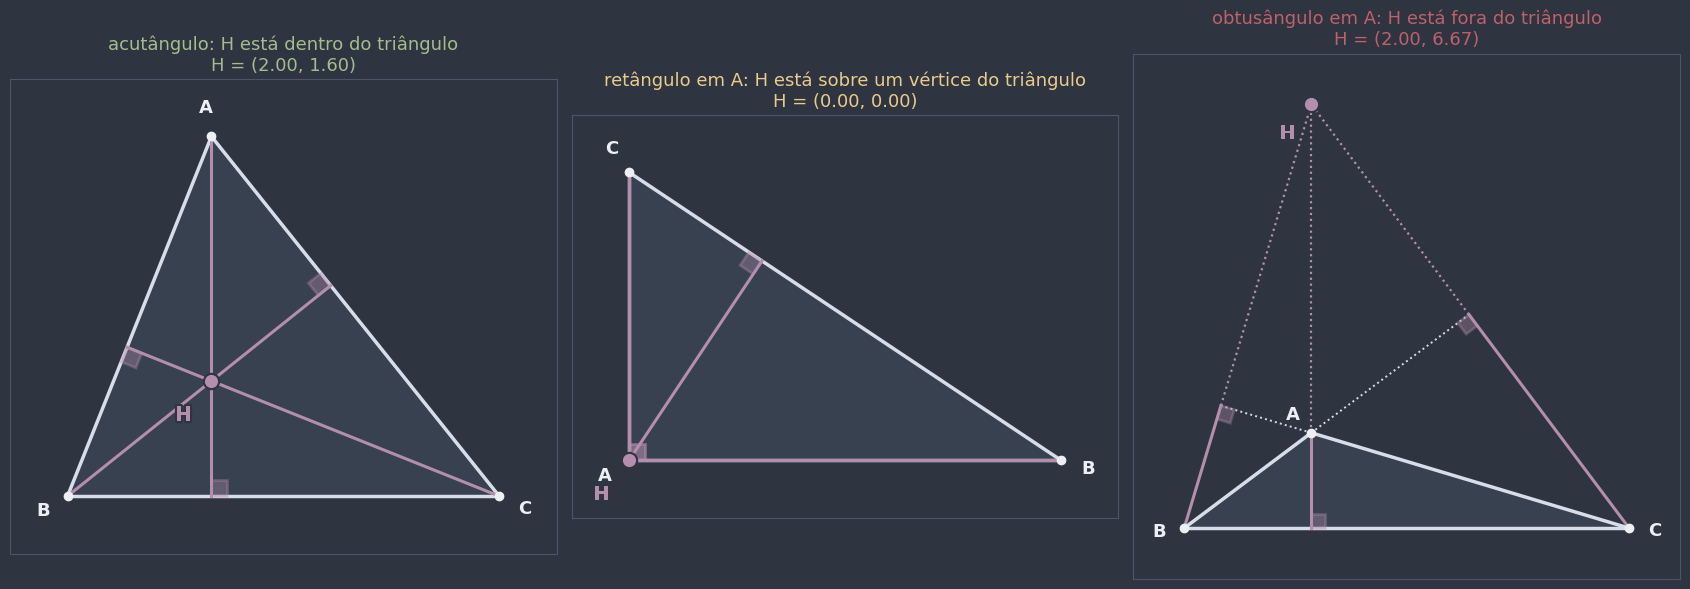

In [15]:
def desenhar_alturas(ax, A, B, C) -> np.ndarray:
    """Desenha as três alturas (cheias), com os prolongamentos pontilhados quando o pé cai fora do lado
    ou quando o ortocentro fica além da altura, e devolve o ortocentro."""
    cor = CORES_NOTAVEIS["H"]
    H = ortocentro(A, B, C)
    for V, P, Q in ((A, B, C), (B, C, A), (C, A, B)):
        F = pe_da_altura(V, P, Q)
        if not esta_no_segmento(F, P, Q):  # o pé caiu no prolongamento do lado PQ
            mais_perto = P if math.dist(F, P) < math.dist(F, Q) else Q
            ax.plot(*zip(mais_perto, F), color=COR_TRIANGULO, lw=1.4, linestyle=":")
        if math.dist(V, F) > 1e-9 and not esta_no_segmento(H, V, F):  # H no prolongamento da altura
            extremo = F if math.dist(H, F) < math.dist(H, V) else V
            ax.plot(*zip(extremo, H), color=cor, lw=1.6, linestyle=":")
        ax.plot(*zip(V, F), color=cor, lw=2.2, zorder=4)
        referencia = Q if math.dist(F, Q) > 1e-9 else P
        marcar_angulo_reto(ax, F, referencia, V, tamanho=0.22, cor=cor)
    marcar_notavel(ax, H, "H")
    return H


fig, eixos = plt.subplots(1, 3, figsize=(17, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (tipo, (A, B, C)) in zip(eixos, TRIANGULOS_TIPOS.items()):
    H = ortocentro(A, B, C)
    pes = [pe_da_altura(V, P, Q) for V, P, Q in ((A, B, C), (B, C, A), (C, A, B))]
    preparar_eixo(ax, [A, B, C, H, *pes], margem=0.8)
    desenhar_triangulo(ax, A, B, C)
    desenhar_alturas(ax, A, B, C)
    posicao = posicao_no_triangulo(H, A, B, C)
    cor = {"dentro": COR_DESTAQUE, "fora": COR_ALERTA}.get(posicao, COR_AVISO)
    ax.set_title(f"{tipo}: H está {posicao} do triângulo\nH = ({H[0]:.2f}, {H[1]:.2f})", color=cor, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o mesmo slider da seção 3, agora acompanhando o ortocentro. Com $\hat{A}$ agudo (e os outros dois ângulos também), $H$ está dentro; em $\hat{A} = 90^\circ$, $H$ **pousa no vértice** $A$; com $\hat{A}$ obtuso, $H$ sai do triângulo pelo lado de $A$ e vai subindo. Compare com o circuncentro: para onde cada um "foge" quando o triângulo fica obtusângulo?

In [ ]:
def explorar_ortocentro(angulo_A: int) -> None:
    A, B, C = triangulo_pelo_angulo_A(angulo_A)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1.6, -1.2), (7.6, 7.8)], margem=0)
    desenhar_triangulo(ax, A, B, C)
    H = desenhar_alturas(ax, A, B, C)
    O = circuncentro(A, B, C)
    ax.plot(*O, "o", color=CORES_NOTAVEIS["O"], markersize=7, alpha=0.6, zorder=7)
    ax.text(O[0] + 0.15, O[1] - 0.45, "O", color=CORES_NOTAVEIS["O"], fontsize=11, alpha=0.8)
    posicao = posicao_no_triangulo(H, A, B, C)
    classificacao = classificar_por_angulos(A, B, C)
    itens = [
        ("H dentro do triângulo (acutângulo)", posicao == "dentro"),
        ("H no vértice A, do ângulo reto (retângulo)", bool(np.allclose(H, A, atol=1e-6))),
        ("H fora do triângulo (obtusângulo)", posicao == "fora"),
        ("pé da altura de B sobre o lado CA", esta_no_segmento(pe_da_altura(B, C, A), C, A)),
        ("pé da altura de C sobre o lado AB", esta_no_segmento(pe_da_altura(C, A, B), A, B)),
    ]
    escrever_checklist(ax_lista, itens, f"Â = {angulo_A}°: triângulo {classificacao}")
    cor = {"acutângulo": COR_DESTAQUE, "retângulo": COR_AVISO, "obtusângulo": COR_ALERTA}[classificacao]
    ax.set_title(f"H = ({H[0]:.2f}, {H[1]:.2f}) está {posicao} do triângulo", color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_ortocentro,
    angulo_A=widgets.IntSlider(value=60, min=45, max=135, step=5, description="ângulo Â (°):",
                               style={"description_width": "initial"}),
);

interactive(children=(IntSlider(value=60, description='ângulo Â (°):', max=135, min=45, step=5, style=SliderSt…

🕵️ **Curiosidade — por que as três alturas se encontram?** *(leitura opcional)* Curiosamente, os *Elementos* de Euclides não incluem esse fato. Uma prova muito elegante, costumeiramente atribuída a **Carl Friedrich Gauss** (início do século XIX), **transforma alturas em mediatrizes** e usa o que já sabemos da seção 3. A ideia é traçar, por cada vértice de $ABC$, a **paralela ao lado oposto** ([`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb)). As três paralelas formam um triângulo maior, $A'B'C'$:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $ABCB'$ e $AC'BC$ são paralelogramos | cada um tem os dois pares de lados opostos paralelos, por construção (0409a) |
| 2 | $AB' = BC$ e $AC' = BC$ | lados opostos de paralelogramo são congruentes (0409a) |
| 3 | $A$ é o ponto médio de $\overline{B'C'}$ | passo 2: $AB' = AC'$, com $A$ entre $B'$ e $C'$ |
| 4 | a altura por $A$ é perpendicular a $\overline{B'C'}$ | ela é perpendicular a $\overline{BC}$, e $\overline{BC} \parallel \overline{B'C'}$ (0407a) |
| 5 | a altura por $A$ é a **mediatriz** de $\overline{B'C'}$ | passos 3 e 4: perpendicular pelo ponto médio |
| 6 | as três alturas de $ABC$ são as três mediatrizes de $A'B'C'$ | o mesmo raciocínio para $B$ e para $C$ |
| 7 | as três alturas se encontram num ponto | as mediatrizes de $A'B'C'$ se encontram (seção 3) ∎ |

Conclusão bonita: **o ortocentro de $ABC$ é o circuncentro do triângulo grande $A'B'C'$.** Com coordenadas, os vértices do triângulo grande são os "quartos cantos" dos paralelogramos: $A' = B + C - A$, $B' = C + A - B$ e $C' = A + B - C$.

A' = [ 4. -5.],  B' = [8. 5.],  C' = [-4.  5.]
A, B e C são os pontos médios de B'C', C'A' e A'B'?  True
ortocentro de ABC = (2.0000, 1.6000);  circuncentro de A'B'C' = (2.0000, 1.6000)


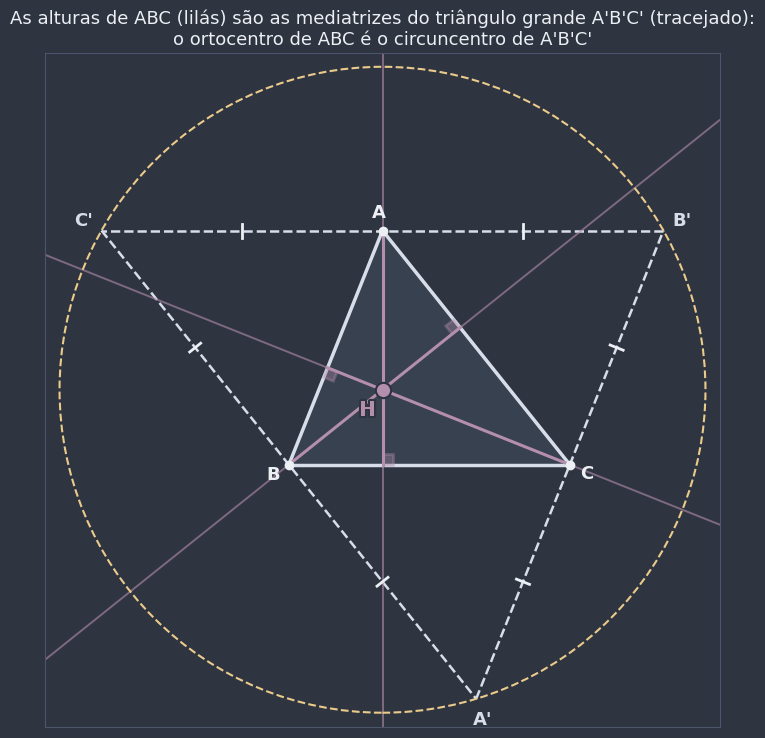

In [17]:
A, B, C = TRIANGULOS_TIPOS["acutângulo"]
A_, B_, C_ = B + C - A, C + A - B, A + B - C  # o triângulo grande A'B'C'
H = ortocentro(A, B, C)
O_grande = circuncentro(A_, B_, C_)
print(f"A' = {A_},  B' = {B_},  C' = {C_}")
print(f"A, B e C são os pontos médios de B'C', C'A' e A'B'?  "
      f"{np.allclose(A, ponto_medio(B_, C_)) and np.allclose(B, ponto_medio(C_, A_)) and np.allclose(C, ponto_medio(A_, B_))}")
print(f"ortocentro de ABC = ({H[0]:.4f}, {H[1]:.4f});  circuncentro de A'B'C' = ({O_grande[0]:.4f}, {O_grande[1]:.4f})")

fig, ax = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor(NORD_FUNDO)
R_grande = math.dist(O_grande, A_)
preparar_eixo(ax, [O_grande + (R_grande, R_grande), O_grande - (R_grande, R_grande)], margem=0.3)
desenhar_circunferencia(ax, O_grande, R_grande, CORES_NOTAVEIS["O"], estilo="--", largura=1.5)
for P, Q in ((A_, B_), (B_, C_), (C_, A_)):
    ax.plot(*zip(P, Q), color=NORD_TEXTO_SEC, lw=1.8, linestyle="--")
for V, P, Q in ((A, B_, C_), (B, C_, A_), (C, A_, B_)):  # cada vértice de ABC é o meio de um lado grande
    marcar_congruentes(ax, P, V, 1, tamanho=0.15)
    marcar_congruentes(ax, V, Q, 1, tamanho=0.15)
    desenhar_reta(ax, V, H, cor=CORES_NOTAVEIS["H"], estilo="-", largura=1.4, alpha=0.6)
desenhar_triangulo(ax, A, B, C)
desenhar_alturas(ax, A, B, C)
for V, nome in ((A_, "A'"), (B_, "B'"), (C_, "C'")):
    rotular_fora(ax, V, nome, O_grande, cor=NORD_TEXTO_SEC, distancia=0.45, tamanho=13)
ax.set_title("As alturas de ABC (lilás) são as mediatrizes do triângulo grande A'B'C' (tracejado):\n"
             "o ortocentro de ABC é o circuncentro de A'B'C'", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — telhados e desenho técnico:** num telhado de duas águas, a **tesoura** (a estrutura triangular que sustenta as telhas) tem a **altura** relativa à base apontando para a **cumeeira**, o ponto mais alto; é essa altura que o carpinteiro mede para cortar o pendural (a peça vertical do meio) e calcular a inclinação. Em desenho técnico e em computação gráfica, as alturas aparecem sempre que é preciso a "distância de um vértice até o lado oposto", por exemplo para saber se um objeto cabe numa abertura triangular ou para calcular áreas. O ortocentro em si aparece em problemas de **otimização** (como o triângulo de menor perímetro inscrito num triângulo acutângulo, que tem os pés das alturas como vértices), um assunto para quem quiser ir além.

📖 **Leitura complementar:** [Altura (geometria)](https://pt.wikipedia.org/wiki/Altura_(geometria)) e [Ortocentro](https://pt.wikipedia.org/wiki/Ortocentro)

**Pergunta de checagem:** em um triângulo retângulo em $A$, onde está o ortocentro? Por quê?

**Pergunta de checagem:** num triângulo obtusângulo, quantas das três alturas têm o pé **sobre** o lado (e não no prolongamento)?

## 5. Visão de conjunto, casos especiais e a reta de Euler

Os quatro pontos lado a lado:

| Ponto | Linhas que se encontram | Propriedade | Acutângulo | Retângulo | Obtusângulo |
|---|---|---|---|---|---|
| **Baricentro** $G$ | 3 medianas | divide cada mediana em 2 : 1; centro de gravidade | dentro | dentro | dentro |
| **Incentro** $I$ | 3 bissetrizes internas | equidistante dos **lados**; centro da circunferência **inscrita** | dentro | dentro | dentro |
| **Circuncentro** $O$ | 3 mediatrizes | equidistante dos **vértices**; centro da circunferência **circunscrita** | dentro | ponto médio da hipotenusa | fora |
| **Ortocentro** $H$ | 3 alturas | encontro das alturas (ou dos prolongamentos) | dentro | vértice do ângulo reto | fora |

**Casos especiais.**

- No triângulo **equilátero**, os **quatro pontos coincidem**. Em cada vértice, a mediana, a bissetriz, a altura e a mediatriz do lado oposto são a **mesma reta** (é a propriedade do isósceles de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb), valendo para as três bases ao mesmo tempo). Só ele tem um "centro" único, sem ambiguidade.
- No triângulo **isósceles** (não equilátero), os quatro pontos são distintos, mas ficam todos sobre o **eixo de simetria**: a altura relativa à base, que também é mediana, bissetriz do ângulo do vértice e mediatriz da base ([`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)). Cada ponto está em três linhas da sua família, e uma delas é justamente esse eixo.

Vamos conferir os dois casos, comparando com um triângulo escaleno.

In [18]:
def pontos_notaveis(A, B, C) -> dict[str, np.ndarray]:
    """Os quatro pontos notáveis do triângulo ABC, no dicionário {"G": ..., "I": ..., "O": ..., "H": ...}."""
    return {"G": baricentro(A, B, C), "I": incentro(A, B, C), "O": circuncentro(A, B, C), "H": ortocentro(A, B, C)}



TRIANGULOS_ESPECIAIS = {
    "equilátero": como_pontos((3, 3 * math.sqrt(3)), (0, 0), (6, 0)),
    "isósceles (AB = AC)": como_pontos((3, 6.5), (0, 0), (6, 0)),
    "escaleno": como_pontos((1.5, 5), (0, 0), (7, 0)),
}

linhas = []
for tipo, (A, B, C) in TRIANGULOS_ESPECIAIS.items():
    pontos = pontos_notaveis(A, B, C)
    afastamento = max(math.dist(P, Q) for P in pontos.values() for Q in pontos.values())
    linhas.append({
        "triângulo": tipo,
        **{f"{letra} ({NOMES_NOTAVEIS[letra]})": f"({P[0]:.3f}, {P[1]:.3f})" for letra, P in pontos.items()},
        "maior distância entre eles": f"{afastamento:.4f}",
        "os quatro coincidem?": "✅" if afastamento < 1e-9 else "❌",
        "todos no eixo x = 3?": "✅" if all(math.isclose(P[0], 3) for P in pontos.values()) else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

triângulo,G (baricentro),I (incentro),O (circuncentro),H (ortocentro),maior distância entre eles,os quatro coincidem?,todos no eixo x = 3?
equilátero,"(3.000, 1.732)","(3.000, 1.732)","(3.000, 1.732)","(3.000, 1.732)",0.0000,✅,✅
isósceles (AB = AC),"(3.000, 2.167)","(3.000, 1.919)","(3.000, 2.558)","(3.000, 1.385)",1.1731,❌,✅
escaleno,"(2.833, 1.667)","(2.394, 1.781)","(3.500, 1.675)","(1.500, 1.650)",2.0002,❌,❌


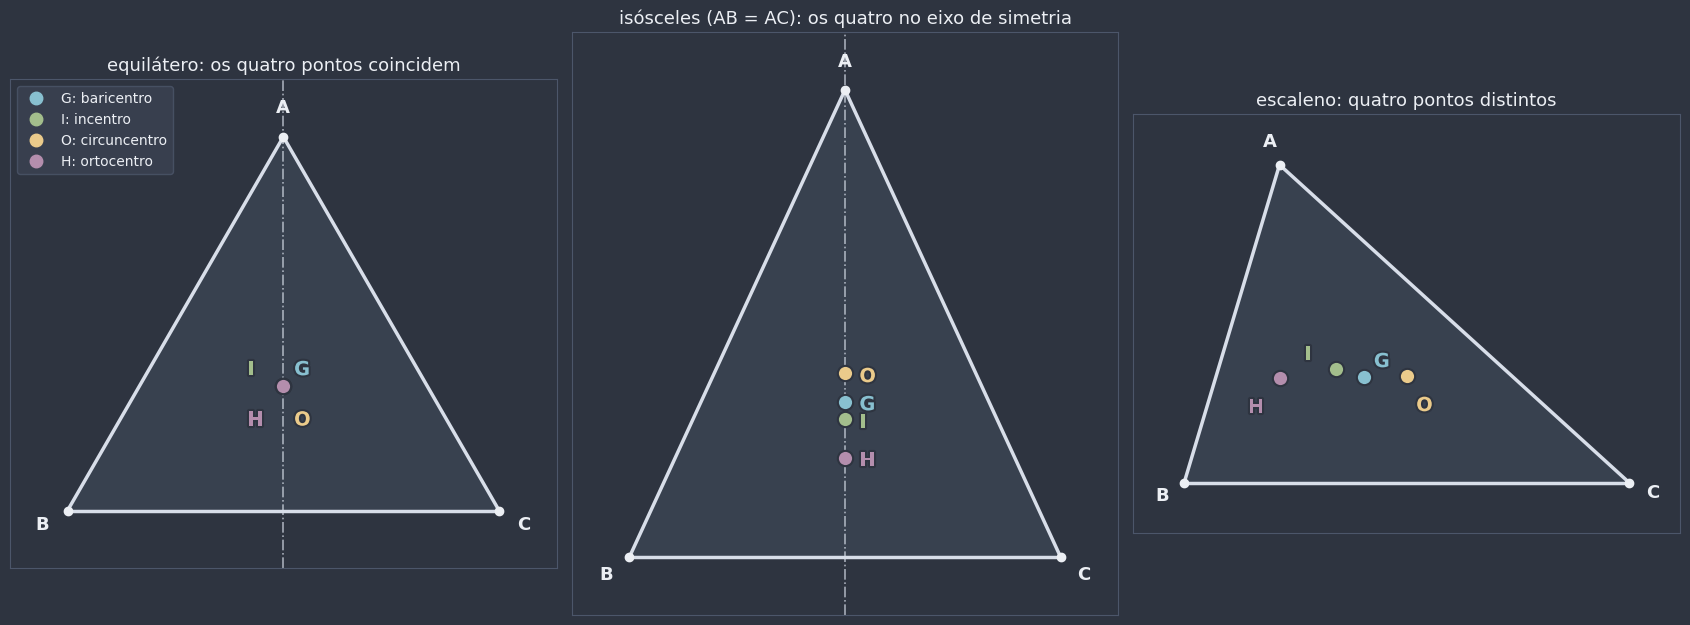

In [19]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 6.6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (tipo, (A, B, C)) in zip(eixos, TRIANGULOS_ESPECIAIS.items()):
    pontos = pontos_notaveis(A, B, C)
    preparar_eixo(ax, [A, B, C, *pontos.values()], margem=0.8)
    if tipo != "escaleno":  # o eixo de simetria x = 3
        ax.axvline(3, color=NORD_TEXTO_SEC, lw=1.2, linestyle="-.", alpha=0.7)
    desenhar_triangulo(ax, A, B, C)
    for letra, P in pontos.items():  # no isósceles os pontos ficam empilhados: rótulos à direita
        marcar_notavel(ax, P, letra, deslocamento=(0.2, -0.12) if tipo.startswith("isósceles") else None)
    titulo = {"equilátero": "os quatro pontos coincidem", "isósceles (AB = AC)": "os quatro no eixo de simetria",
              "escaleno": "quatro pontos distintos"}[tipo]
    ax.set_title(f"{tipo}: {titulo}", color=NORD_TEXTO, fontsize=13)
eixos[0].legend(handles=[plt.Line2D([], [], marker="o", color=CORES_NOTAVEIS[letra], linestyle="", markersize=9,
                                    label=f"{letra}: {NOMES_NOTAVEIS[letra]}") for letra in "GIOH"],
                facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO, loc="upper left")
plt.tight_layout()
plt.show()

Olhe de novo o triângulo **escaleno** acima. Os quatro pontos estão espalhados, mas três deles parecem... **alinhados**? Não é coincidência.

🕵️ **Curiosidade histórica — a reta de Euler:** em 1765, o matemático suíço **Leonhard Euler** (o mesmo das funções, dos grafos e de metade das fórmulas que você ainda vai encontrar) mostrou que, em **qualquer** triângulo não equilátero, o **ortocentro $H$, o baricentro $G$ e o circuncentro $O$ são colineares**. Mais do que isso: $G$ fica **entre** os outros dois e divide o segmento $\overline{HO}$ na razão

$$HG : GO = 2 : 1, \qquad \text{ou seja,} \qquad HG = 2 \cdot GO.$$

A reta que passa pelos três é chamada **reta de Euler** do triângulo. Mais de 2000 anos depois de Euclides, ainda havia fatos simples e bonitos sobre o triângulo esperando para serem descobertos.

⚠️ **Erro comum:** dizer que "os **quatro** pontos notáveis são sempre colineares". São só **três**: $H$, $G$ e $O$. O **incentro** é o "intruso": em geral, ele **não** está na reta de Euler (só está quando o triângulo é isósceles, porque aí os quatro estão no eixo de simetria).

Vamos testar em vários triângulos sorteados. Para saber se $H$, $G$ e $O$ estão alinhados, usamos a multiplicação cruzada (zero ⇔ colineares); para medir o quanto o incentro está fora da reta, a distância de ponto a reta de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb).

In [20]:
gerador = np.random.default_rng(2026)
linhas = []
while len(linhas) < 8:
    A, B, C = gerador.uniform(-5, 5, (3, 2))
    if min(angulos_do_triangulo(A, B, C)) < 10:  # descarta triângulos achatados demais (H e O vão longe)
        continue
    pontos = pontos_notaveis(A, B, C)
    H, G, O, I = pontos["H"], pontos["G"], pontos["O"], pontos["I"]
    linhas.append({
        "triângulo": len(linhas) + 1,
        "classificação": classificar_por_angulos(A, B, C),
        "H, G, O alinhados?": "✅" if math.isclose(orientacao(H, G, O), 0, abs_tol=1e-9) else "❌",
        "G entre H e O?": "✅" if esta_no_segmento(G, H, O) else "❌",
        "HG": f"{math.dist(H, G):.4f}",
        "GO": f"{math.dist(G, O):.4f}",
        "HG ÷ GO": f"{math.dist(H, G) / math.dist(G, O):.6f}",
        "distância de I à reta de Euler": f"{distancia_ponto_reta(I, H, direcao_de(H, O)):.4f}",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

triângulo,classificação,"H, G, O alinhados?",G entre H e O?,HG,GO,HG ÷ GO,distância de I à reta de Euler
1,acutângulo,✅,✅,1.1973,0.5986,2.000000,0.2163
2,acutângulo,✅,✅,2.4140,1.2070,2.000000,0.5748
3,obtusângulo,✅,✅,1.9273,0.9637,2.000000,0.6035
4,acutângulo,✅,✅,0.7362,0.3681,2.000000,0.0012
5,obtusângulo,✅,✅,4.1268,2.0634,2.000000,1.1405
6,obtusângulo,✅,✅,4.2268,2.1134,2.000000,0.0823
7,obtusângulo,✅,✅,4.7308,2.3654,2.000000,0.7435
8,obtusângulo,✅,✅,1.0717,0.5358,2.000000,0.0583


Nos oito triângulos: $H$, $G$ e $O$ alinhados, $G$ entre eles, e $HG \div GO = 2$ (a menos de arredondamentos da ordem de $10^{-15}$). E o incentro, fora da reta em todos.

🕹️ **Widget interativo:** mova os vértices e observe os quatro pontos (cada um na sua cor) e a **reta de Euler**, em vermelho. $H$, $G$ e $O$ continuam alinhados em qualquer posição, enquanto $I$ "sai" da reta. Experimente: (1) deixar o triângulo **isósceles** (por exemplo, $B = (0, 0)$, $C = (8, 0)$ e $A$ com $x = 4$) e ver $I$ "entrar" na reta; (2) chegar perto de um **equilátero** ($A = (4;\ 6{,}9)$, aproximadamente) e ver os quatro pontos se juntarem; (3) deixar o triângulo **retângulo** e ver onde a reta de Euler passa.

In [21]:
def explorar_euler(A, B, C) -> None:
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.4), gridspec_kw={"width_ratios": [1.2, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-3, -3), (11, 11)], margem=0)
    if not eh_triangulo(A, B, C):
        avisar_colineares(ax, ax_lista, A, B, C)
        plt.show()
        return
    pontos = pontos_notaveis(A, B, C)
    H, G, O, I = pontos["H"], pontos["G"], pontos["O"], pontos["I"]
    desenhar_circunferencia(ax, O, math.dist(O, A), CORES_NOTAVEIS["O"], estilo=":", largura=1.2)
    equilatero = math.dist(H, O) < 1e-6
    if not equilatero:
        desenhar_reta(ax, H, O, cor=COR_EULER, estilo="-", largura=2, alpha=0.85)
    desenhar_triangulo(ax, A, B, C)
    for letra, P in pontos.items():
        marcar_notavel(ax, P, letra)
    if equilatero:
        itens = [("triângulo equilátero: G = I = O = H", True),
                 ("(não há reta de Euler: os pontos coincidem)", True)]
    else:
        distancia_I = distancia_ponto_reta(I, H, direcao_de(H, O))
        itens = [
            ("H, G e O alinhados", math.isclose(orientacao(H, G, O), 0, abs_tol=1e-6 * max(1, math.dist(H, O)))),
            ("G entre H e O", esta_no_segmento(G, H, O)),
            (f"HG = {math.dist(H, G):.3f} = 2 × GO = 2 × {math.dist(G, O):.3f}",
             iguais(math.dist(H, G), 2 * math.dist(G, O))),
            (f"I na reta de Euler?  distância = {distancia_I:.3f}", distancia_I < 1e-6),
        ]
    lados = lados_do_triangulo(A, B, C)
    isosceles = any(math.isclose(lados[k], lados[k - 1], abs_tol=1e-9) for k in range(3))
    escrever_checklist(ax_lista, itens, "A reta de Euler" + ("  (triângulo isósceles)" if isosceles else ""))
    ax.legend(handles=[plt.Line2D([], [], marker="o", color=CORES_NOTAVEIS[letra], linestyle="", markersize=9,
                                  label=f"{letra}: {NOMES_NOTAVEIS[letra]}") for letra in "GIOH"]
              + [plt.Line2D([], [], color=COR_EULER, lw=2, label="reta de Euler")],
              facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO, loc="upper right", fontsize=9)
    ax.set_title(f"Triângulo {classificar_por_angulos(A, B, C)}", color=NORD_TEXTO, fontsize=13)
    plt.tight_layout()
    plt.show()


painel_de_vertices(explorar_euler, (1, 6.5), (0, 0), (8, 0))

Output()

💡 **Dica:** no triângulo **retângulo** em $A$, a reta de Euler é a **mediana relativa à hipotenusa**: ela liga $H = A$ (seção 4) a $O = M_a$, o ponto médio da hipotenusa (seção 3), e $G$, que está em toda mediana, fica nela também.

📖 **Leitura complementar:** [Reta de Euler](https://pt.wikipedia.org/wiki/Reta_de_Euler)

**Pergunta de checagem:** em qual triângulo o baricentro, o incentro, o circuncentro e o ortocentro são o mesmo ponto?

**Pergunta de checagem:** na reta de Euler de um triângulo, a distância entre o ortocentro e o circuncentro é $HO = 9$ cm. Quanto medem $HG$ e $GO$?

## Resumo — cheat sheet

| Ponto | Linhas que se encontram | Propriedade-chave | Posição |
|---|---|---|---|
| **Baricentro** $G$ | 3 **medianas** (vértice → ponto médio do lado oposto) | divide cada mediana em **2 : 1** a partir do vértice; centro de gravidade | **sempre dentro** |
| **Incentro** $I$ | 3 **bissetrizes internas** | equidistante dos **lados**; centro da circunferência **inscrita** (raio $r$) | **sempre dentro** |
| **Circuncentro** $O$ | 3 **mediatrizes** (perpendicular pelo ponto médio) | equidistante dos **vértices**; centro da circunferência **circunscrita** (raio $R$) | dentro (acutângulo), **no meio da hipotenusa** (retângulo), fora (obtusângulo) |
| **Ortocentro** $H$ | 3 **alturas** (vértice ⊥ reta do lado oposto) | encontro das alturas ou de seus prolongamentos | dentro (acutângulo), **no vértice do ângulo reto** (retângulo), fora (obtusângulo) |

| Fórmula / fato | Ideia-chave |
|---|---|
| $G = \dfrac{A + B + C}{3}$ | a média das coordenadas; $AG = \frac{2}{3}AM_a$ |
| $I = \dfrac{a \cdot A + b \cdot B + c \cdot C}{a + b + c}$ | média ponderada pelos lados opostos; $r = \operatorname{dist}(I, \text{qualquer lado})$ |
| $OA = OB = OC = R$ | no triângulo retângulo, $R = \dfrac{\text{hipotenusa}}{2}$ |
| Lugares geométricos | mediatriz: equidistantes de **dois pontos**; bissetriz: equidistantes de **duas retas** |
| Por que concorrem | $O$ e $I$: "equidistante de 1 e 2, e de 2 e 3 ⇒ de 1 e 3"; $G$: o ponto a $\frac{2}{3}$ de cada mediana é o mesmo; $H$: as alturas são as mediatrizes do triângulo $A'B'C'$ |
| Equilátero | os **quatro** pontos coincidem |
| Isósceles | os quatro pontos ficam no **eixo de simetria** |
| **Reta de Euler** | $H$, $G$ e $O$ são colineares, com $HG = 2 \cdot GO$; o incentro, em geral, fica **fora** |
| Mnemônico | **In**centro ↔ circunferência **in**scrita; **Circun**centro ↔ circunferência **circun**scrita |

**A ideia central:** "centro do triângulo" tem quatro significados, um para cada família de linhas notáveis. Os dois que vêm de linhas que **saem dos vértices e terminam no lado oposto** (medianas e bissetrizes) ficam sempre dentro; os dois que vêm de **perpendiculares** (mediatrizes e alturas) dependem da forma do triângulo, e saem dele quando há um ângulo obtuso.

## Exercícios

**Básico**
1. Calcular o baricentro de um triângulo dado por coordenadas e verificar a razão 2 : 1 numa mediana.
2. Dizer, sem calcular, onde ficam o circuncentro e o ortocentro em cada tipo de triângulo.

**Intermediário**

3. Escrever as funções que calculam os quatro pontos notáveis e validá-las em triângulos conhecidos (equilátero e retângulo).
4. Calcular o raio da circunferência inscrita e o da circunscrita do triângulo de lados 13, 14 e 15.

**Desafio**

5. A reta de Euler em 100 triângulos sorteados, e o incentro em triângulos isósceles.
6. Um problema de localização com três bairros que formam um triângulo obtusângulo.

Gabarito completo com resolução comentada em [`0410b_pontos_notaveis_do_triangulo_gabarito.ipynb`](0410b_pontos_notaveis_do_triangulo_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1:
# O triângulo ABC tem vértices A = (2, 7), B = (−1, 1) e C = (8, 1).
# (a) Calcule o ponto médio M_a do lado BC (o lado oposto a A) e guarde em `M_a_ex1`.
# (b) Calcule o baricentro G (a média das coordenadas dos vértices) e guarde em `G_ex1`.
# (c) Calcule AG e GM_a (com math.dist) e guarde a razão AG / GM_a em `razao_ex1`.
# (d) Uma mediana de outro triângulo mede 12 cm. Quanto mede o trecho entre o vértice e o
#     baricentro? Guarde em `trecho_vertice_ex1`. E entre o baricentro e o ponto médio do lado?
#     Guarde em `trecho_lado_ex1`.
A_ex1, B_ex1, C_ex1 = como_pontos((2, 7), (-1, 1), (8, 1))

M_a_ex1 = ...
G_ex1 = ...
razao_ex1 = ...
trecho_vertice_ex1 = ...
trecho_lado_ex1 = ...

print(M_a_ex1, G_ex1, razao_ex1)
print(trecho_vertice_ex1, trecho_lado_ex1)

In [ ]:
# Verificação
assert M_a_ex1 is not ... and np.allclose(M_a_ex1, (3.5, 1)), (
    "Tente de novo, revise: M_a = ponto_medio(B_ex1, C_ex1), a média das coordenadas de B e C "
    "(seção 1 - Baricentro: o ponto das medianas)."
)
assert G_ex1 is not ... and np.allclose(G_ex1, (3, 3)), (
    "Tente de novo, revise: G = (A + B + C) / 3, coordenada a coordenada "
    "(seção 1 - Baricentro: o ponto das medianas)."
)
assert razao_ex1 is not ... and math.isclose(razao_ex1, 2), (
    "Tente de novo, revise: razão = math.dist(A_ex1, G_ex1) / math.dist(G_ex1, M_a_ex1); o baricentro "
    "divide a mediana em 2 : 1 (seção 1 - Baricentro: o ponto das medianas)."
)
assert trecho_vertice_ex1 is not ... and trecho_lado_ex1 is not ... and math.isclose(trecho_vertice_ex1, 8) \
    and math.isclose(trecho_lado_ex1, 4), (
    "Tente de novo, revise: a mediana é dividida em 3 partes iguais, 2 do lado do vértice e 1 do lado do "
    "ponto médio (seção 1 - Baricentro: o ponto das medianas)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2:
# (a) Complete os dicionários `posicao_O_ex2` (circuncentro) e `posicao_H_ex2` (ortocentro). As chaves
#     são "acutângulo", "retângulo" e "obtusângulo"; os valores, um destes textos:
#     "dentro", "sobre o triângulo" ou "fora".
# (b) Complete a função `onde_ficam_ex2`, que recebe a tupla com os três ângulos internos (em graus) de
#     um triângulo e devolve a tupla (classificacao, posicao_O, posicao_H), em que classificacao é
#     "acutângulo", "retângulo" ou "obtusângulo" (olhe para o MAIOR ângulo) e as posições saem dos
#     dicionários do item (a).
# (c) Quais pontos notáveis ficam SEMPRE dentro do triângulo, qualquer que seja ele? Guarde o conjunto
#     das letras (entre "G", "I", "O" e "H") em `sempre_dentro_ex2`.
posicao_O_ex2 = ...
posicao_H_ex2 = ...


def onde_ficam_ex2(angulos: tuple[float, float, float]) -> tuple[str, str, str]:
    ...


sempre_dentro_ex2 = ...

print(onde_ficam_ex2((50, 60, 70)))
print(onde_ficam_ex2((20, 30, 130)))
print(sempre_dentro_ex2)

In [ ]:
# Verificação
assert isinstance(posicao_O_ex2, dict) and isinstance(posicao_H_ex2, dict), (
    "Tente de novo, revise: `posicao_O_ex2` e `posicao_H_ex2` devem ser dicionários "
    "(seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
)
for tipo, certo in {"acutângulo": "dentro", "retângulo": "sobre o triângulo", "obtusângulo": "fora"}.items():
    assert posicao_O_ex2.get(tipo) == certo, (
        f"Tente de novo, revise: no triângulo {tipo}, o circuncentro fica {certo!r} "
        "(seção 3 - Circuncentro: o ponto das mediatrizes)."
    )
    assert posicao_H_ex2.get(tipo) == certo, (
        f"Tente de novo, revise: no triângulo {tipo}, o ortocentro fica {certo!r} "
        "(seção 4 - Ortocentro: o ponto das alturas)."
    )
casos_ex2 = [((50, 60, 70), "acutângulo"), ((30, 60, 90), "retângulo"), ((20, 30, 130), "obtusângulo"),
             ((90, 45, 45), "retângulo"), ((100, 40, 40), "obtusângulo"), ((60, 60, 60), "acutângulo"),
             ((89.5, 45, 45.5), "acutângulo")]
for angulos, tipo in casos_ex2:
    resposta = onde_ficam_ex2(angulos)
    assert resposta is not None and resposta is not ... and tuple(resposta) == (tipo, posicao_O_ex2[tipo],
                                                                               posicao_H_ex2[tipo]), (
        f"Tente de novo, revise: com ângulos {angulos}, o maior ângulo indica um triângulo {tipo} "
        "(seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
    )
assert sempre_dentro_ex2 is not ... and set(sempre_dentro_ex2) == {"G", "I"}, (
    "Tente de novo, revise: medianas e bissetrizes internas ligam um vértice ao lado oposto, ficando "
    "inteiras dentro do triângulo (seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: os quatro pontos notáveis, com as suas próprias funções.
# Complete as funções abaixo. Cada uma recebe os vértices A, B, C (np.array) e devolve o ponto
# (np.array). Não vale chamar as funções prontas do notebook (baricentro, incentro, circuncentro,
# ortocentro): monte cada uma com as ferramentas ponto_medio, cruzamento, direcao_de,
# inclinacao_da_perpendicular, direcao_da_bissetriz e lados_do_triangulo.
#   - baricentro_ex3: a média das coordenadas;
#   - incentro_ex3: o cruzamento de duas bissetrizes internas (ou a fórmula da média ponderada);
#   - circuncentro_ex3: o cruzamento de duas mediatrizes;
#   - ortocentro_ex3: o cruzamento de duas alturas.
# A verificação testa um triângulo equilátero (os quatro iguais), um triângulo retângulo
# (circuncentro no meio da hipotenusa e ortocentro no vértice do ângulo reto) e 20 triângulos sorteados.


def baricentro_ex3(A, B, C) -> np.ndarray:
    ...


def incentro_ex3(A, B, C) -> np.ndarray:
    ...


def circuncentro_ex3(A, B, C) -> np.ndarray:
    ...


def ortocentro_ex3(A, B, C) -> np.ndarray:
    ...


A_teste, B_teste, C_teste = como_pontos((0, 0), (8, 0), (0, 6))
print(baricentro_ex3(A_teste, B_teste, C_teste), incentro_ex3(A_teste, B_teste, C_teste))
print(circuncentro_ex3(A_teste, B_teste, C_teste), ortocentro_ex3(A_teste, B_teste, C_teste))

In [ ]:
# Verificação
funcoes_ex3 = {"G": baricentro_ex3, "I": incentro_ex3, "O": circuncentro_ex3, "H": ortocentro_ex3}
secoes_ex3 = {"G": "seção 1 - Baricentro: o ponto das medianas", "I": "seção 2 - Incentro: o ponto das bissetrizes internas",
              "O": "seção 3 - Circuncentro: o ponto das mediatrizes", "H": "seção 4 - Ortocentro: o ponto das alturas"}
equilatero_ex3 = como_pontos((0, 0), (6, 0), (3, 3 * math.sqrt(3)))
for letra, funcao in funcoes_ex3.items():
    resposta = funcao(*equilatero_ex3)
    assert resposta is not None and resposta is not ... and np.allclose(resposta, (3, math.sqrt(3))), (
        f"Tente de novo, revise: no equilátero de vértices (0, 0), (6, 0) e (3, 3√3), o {NOMES_NOTAVEIS[letra]} "
        f"é (3, √3), como os outros três ({secoes_ex3[letra]})."
    )
retangulo_ex3 = como_pontos((0, 0), (8, 0), (0, 6))  # retângulo em A, hipotenusa BC
assert np.allclose(circuncentro_ex3(*retangulo_ex3), (4, 3)), (
    "Tente de novo, revise: no triângulo retângulo, o circuncentro é o ponto médio da hipotenusa "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert np.allclose(ortocentro_ex3(*retangulo_ex3), (0, 0)), (
    "Tente de novo, revise: no triângulo retângulo, o ortocentro é o vértice do ângulo reto "
    "(seção 4 - Ortocentro: o ponto das alturas)."
)
assert np.allclose(incentro_ex3(*retangulo_ex3), (2, 2)), (
    "Tente de novo, revise: as bissetrizes internas de dois ângulos, cruzadas com `cruzamento` "
    "(seção 2 - Incentro: o ponto das bissetrizes internas)."
)
gerador_ex3 = np.random.default_rng(3)
for _ in range(20):
    vertices = gerador_ex3.uniform(-10, 10, (3, 2))
    for letra, funcao in funcoes_ex3.items():
        assert np.allclose(funcao(*vertices), pontos_notaveis(*vertices)[letra]), (
            f"Tente de novo, revise: o {NOMES_NOTAVEIS[letra]} do triângulo {vertices.round(2).tolist()} "
            f"não confere ({secoes_ex3[letra]})."
        )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: as circunferências inscrita e circunscrita do triângulo 13-14-15.
# O triângulo de vértices A = (0, 0), B = (14, 0) e C = (5, 12) tem lados AB = 14, BC = 15 e CA = 13.
# (a) Calcule o incentro e guarde em `I_ex4`. Depois, calcule a lista das distâncias de I aos lados
#     BC, CA e AB (use distancia_ponto_reta, ou distancias_aos_lados) e guarde em `dist_lados_ex4`.
#     Guarde o raio da circunferência inscrita em `r_ex4`.
# (b) Calcule o circuncentro e guarde em `O_ex4`. Calcule a lista das distâncias de O aos vértices
#     A, B e C e guarde em `dist_vertices_ex4`. Guarde o raio da circunferência circunscrita em `R_ex4`.
# (c) Calcule a razão R / r e guarde em `R_sobre_r_ex4`. (Ela é maior ou menor que 2?)
A_ex4, B_ex4, C_ex4 = como_pontos((0, 0), (14, 0), (5, 12))

I_ex4 = ...
dist_lados_ex4 = ...
r_ex4 = ...
O_ex4 = ...
dist_vertices_ex4 = ...
R_ex4 = ...
R_sobre_r_ex4 = ...

print(I_ex4, dist_lados_ex4, r_ex4)
print(O_ex4, dist_vertices_ex4, R_ex4, R_sobre_r_ex4)

In [ ]:
# Verificação
assert I_ex4 is not ... and np.allclose(I_ex4, (6, 4)), (
    "Tente de novo, revise: I = incentro(A_ex4, B_ex4, C_ex4), ou a fórmula (a·A + b·B + c·C) / (a + b + c) "
    "com a = 15, b = 13, c = 14 (seção 2 - Incentro: o ponto das bissetrizes internas)."
)
assert dist_lados_ex4 is not ... and len(dist_lados_ex4) == 3 and np.allclose(dist_lados_ex4, 4), (
    "Tente de novo, revise: as três distâncias de I aos lados são iguais; use distancias_aos_lados(I_ex4, A_ex4, "
    "B_ex4, C_ex4) (seção 2 - Incentro: o ponto das bissetrizes internas)."
)
assert r_ex4 is not ... and math.isclose(r_ex4, 4), (
    "Tente de novo, revise: o raio da circunferência inscrita é a distância comum de I aos lados "
    "(seção 2 - Incentro: o ponto das bissetrizes internas)."
)
assert O_ex4 is not ... and np.allclose(O_ex4, (7, 4.125)), (
    "Tente de novo, revise: O = circuncentro(A_ex4, B_ex4, C_ex4), o cruzamento de duas mediatrizes "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert dist_vertices_ex4 is not ... and len(dist_vertices_ex4) == 3 and np.allclose(dist_vertices_ex4, 8.125), (
    "Tente de novo, revise: [math.dist(O_ex4, V) for V in (A_ex4, B_ex4, C_ex4)] dá três valores iguais "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert R_ex4 is not ... and math.isclose(R_ex4, 8.125), (
    "Tente de novo, revise: o raio circunscrito é a distância comum de O aos vértices "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert R_sobre_r_ex4 is not ... and math.isclose(R_sobre_r_ex4, 8.125 / 4), (
    "Tente de novo, revise: R_sobre_r = R_ex4 / r_ex4 (seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: a reta de Euler, testada em massa.
# (a) Sorteie 100 triângulos com o gerador abaixo (cada um: gerador_ex5.uniform(-10, 10, (3, 2))),
#     descartando os que tiverem algum ângulo menor que 5° (angulos_do_triangulo), até juntar 100.
#     Para cada um, calcule H, G e O e verifique:
#       - se são colineares: math.isclose(orientacao(H, G, O), 0, abs_tol=1e-6);
#       - se HG = 2·GO: math.isclose(math.dist(H, G), 2 * math.dist(G, O), rel_tol=1e-6).
#     Guarde em `todos_colineares_ex5` True se TODOS forem colineares, e em `todas_razoes_ex5` True se
#     TODOS tiverem HG = 2·GO.
# (b) Nesses mesmos 100 triângulos, calcule a fração (entre 0 e 1) dos que têm o incentro sobre a
#     reta de Euler (distância de I à reta HO menor que 1e-6). Guarde em `fracao_I_na_reta_ex5`.
# (c) A função `isosceles_aleatorio_ex5` (pronta, abaixo) sorteia um triângulo isósceles em posição
#     qualquer (girado e deslocado). Sorteie 50 deles e guarde em `isosceles_I_na_reta_ex5` True se,
#     em TODOS, o incentro estiver sobre a reta de Euler (mesmo critério do item b).
gerador_ex5 = np.random.default_rng(5)


def isosceles_aleatorio_ex5(gerador) -> list[np.ndarray]:
    """Triângulo isósceles (AB = AC) com base, altura, giro e posição sorteados."""
    meia_base, altura = gerador.uniform(1, 6, 2)
    giro = gerador.uniform(0, 360)
    deslocamento = gerador.uniform(-5, 5, 2)
    A, B, C = np.array([0.0, altura]), np.array([-meia_base, 0.0]), np.array([meia_base, 0.0])
    rotacao = np.column_stack([direcao(giro), direcao(giro + 90)])  # gira os pontos em torno da origem
    return [rotacao @ V + deslocamento for V in (A, B, C)]


todos_colineares_ex5 = ...
todas_razoes_ex5 = ...
fracao_I_na_reta_ex5 = ...
isosceles_I_na_reta_ex5 = ...

print(todos_colineares_ex5, todas_razoes_ex5, fracao_I_na_reta_ex5, isosceles_I_na_reta_ex5)

In [ ]:
# Verificação
assert todos_colineares_ex5 is True or todos_colineares_ex5 is np.True_, (
    "Tente de novo, revise: H, G e O são colineares em todo triângulo; confira o laço, o descarte dos "
    "triângulos achatados e o teste com orientacao (seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
)
assert todas_razoes_ex5 is True or todas_razoes_ex5 is np.True_, (
    "Tente de novo, revise: compare math.dist(H, G) com 2 * math.dist(G, O), nessa ordem "
    "(seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
)
assert fracao_I_na_reta_ex5 is not ... and math.isclose(fracao_I_na_reta_ex5, 0, abs_tol=1e-9), (
    "Tente de novo, revise: em triângulos sorteados ao acaso (quase nunca isósceles), o incentro fica fora "
    "da reta de Euler; use distancia_ponto_reta(I, H, direcao_de(H, O)) (seção 5 - Visão de conjunto, "
    "casos especiais e a reta de Euler)."
)
assert isosceles_I_na_reta_ex5 is True or isosceles_I_na_reta_ex5 is np.True_, (
    "Tente de novo, revise: no isósceles, os quatro pontos estão no eixo de simetria; confira o teste da "
    "distância de I à reta HO (seção 5 - Visão de conjunto, casos especiais e a reta de Euler)."
)
print("Certo!")

Execute a célula abaixo para ver o mapa do Exercício Desafio 6.

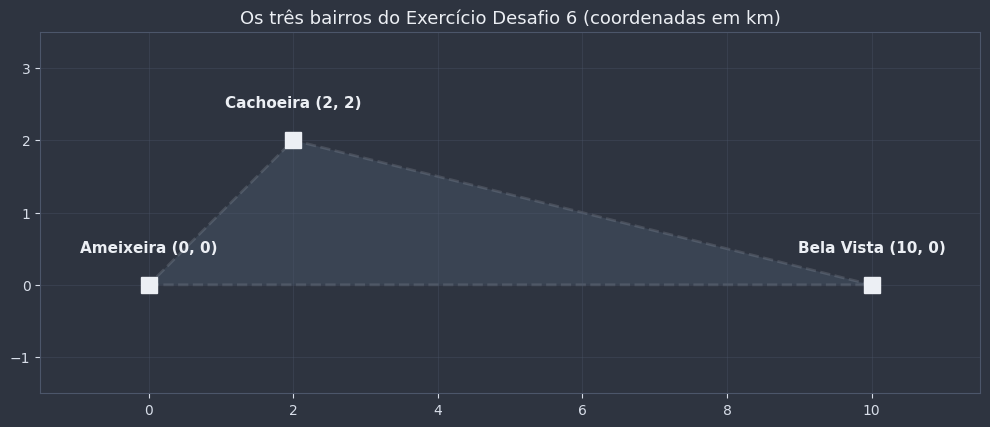

In [22]:
# Mapa do Exercício Desafio 6 (apenas desenha; não precisa alterar)
BAIRROS_EX6 = dict(zip(["Ameixeira", "Bela Vista", "Cachoeira"], como_pontos((0, 0), (10, 0), (2, 2))))
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.set_aspect("equal")
ax.set_xlim(-1.5, 11.5)
ax.set_ylim(-1.5, 3.5)
ax.add_patch(Polygon(list(BAIRROS_EX6.values()), closed=True, facecolor=COR_SECUNDARIA, alpha=0.15, edgecolor=COR_TRIANGULO,
                     lw=2, linestyle="--"))
for nome, P in BAIRROS_EX6.items():
    ax.plot(*P, "s", color=NORD_TEXTO, markersize=11, zorder=5)
    ax.text(P[0], P[1] + 0.45, f"{nome} {tuple(int(c) for c in P)}", color=NORD_TEXTO, fontsize=11, ha="center",
            fontweight="bold")
ax.set_title("Os três bairros do Exercício Desafio 6 (coordenadas em km)", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 6: um posto de saúde para três bairros.
# A prefeitura quer construir UM posto de saúde para os bairros Ameixeira A = (0, 0), Bela Vista
# B = (10, 0) e Cachoeira C = (2, 2) (coordenadas em km, no dicionário BAIRROS_EX6 da célula acima).
# (a) Classifique o triângulo ABC quanto aos ângulos e guarde em `classificacao_ex6`.
# (b) O primeiro projeto põe o posto à mesma distância dos três bairros. Calcule esse ponto e guarde em
#     `O_ex6`; guarde a distância comum (em km) em `R_ex6`.
# (c) Onde fica esse ponto em relação ao triângulo? Guarde "dentro", "sobre o triângulo" ou "fora" em
#     `posicao_ex6`.
# (d) Um segundo projeto põe o posto no ponto médio M do MAIOR lado do triângulo. Guarde M em `M_ex6`
#     e a MAIOR das três distâncias de M aos bairros em `maior_distancia_M_ex6`.
# (e) Se o objetivo é que o morador mais distante ande o MENOS possível, qual projeto é melhor?
#     Guarde "O" ou "M" em `melhor_projeto_ex6`.
A_ex6, B_ex6, C_ex6 = BAIRROS_EX6.values()

classificacao_ex6 = ...
O_ex6 = ...
R_ex6 = ...
posicao_ex6 = ...
M_ex6 = ...
maior_distancia_M_ex6 = ...
melhor_projeto_ex6 = ...

print(classificacao_ex6, O_ex6, R_ex6, posicao_ex6)
print(M_ex6, maior_distancia_M_ex6, melhor_projeto_ex6)

In [ ]:
# Verificação
assert classificacao_ex6 == "obtusângulo", (
    "Tente de novo, revise: meça os ângulos com angulos_do_triangulo; o ângulo em C passa de 90° "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert O_ex6 is not ... and np.allclose(O_ex6, (5, -3)), (
    "Tente de novo, revise: o ponto equidistante dos três vértices é o circuncentro "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert R_ex6 is not ... and math.isclose(R_ex6, math.sqrt(34)), (
    "Tente de novo, revise: R = math.dist(O_ex6, A_ex6) (seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert posicao_ex6 == "fora", (
    "Tente de novo, revise: no triângulo obtusângulo, o circuncentro fica fora do triângulo "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert M_ex6 is not ... and np.allclose(M_ex6, (5, 0)), (
    "Tente de novo, revise: o maior lado é AB (oposto ao ângulo obtuso), e M = ponto_medio(A_ex6, B_ex6) "
    "(seção 1 - Baricentro: o ponto das medianas)."
)
assert maior_distancia_M_ex6 is not ... and math.isclose(maior_distancia_M_ex6, 5), (
    "Tente de novo, revise: max(math.dist(M_ex6, V) for V in (A_ex6, B_ex6, C_ex6)) "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
assert melhor_projeto_ex6 == "M", (
    "Tente de novo, revise: compare R_ex6 (a distância de O a cada bairro) com maior_distancia_M_ex6 "
    "(seção 3 - Circuncentro: o ponto das mediatrizes)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio, nas medianas e nas mediatrizes)
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (bissetriz de um ângulo, nas bissetrizes internas)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (elementos do triângulo, a convenção $a = BC$, $b = CA$, $c = AB$ e a classificação quanto aos ângulos, que decide a posição de $O$ e $H$)
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (o caso LAAo na bissetriz como lugar geométrico; mediana, bissetriz e altura coincidindo no isósceles)
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (as paralelas pelos vértices na demonstração do ortocentro)
- [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (perpendicular por um ponto, projeção ortogonal, distância de ponto a reta e a mediatriz como lugar geométrico; o Desafio 5, que antecipou o circuncentro)
- [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) (as diagonais do losango como bissetrizes e as do retângulo no caso do triângulo retângulo; os paralelogramos da demonstração do ortocentro)

**Isso será usado em:**
- [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb) (circunferências inscrita e circunscrita, quadriláteros inscritíveis e circunscritíveis)
- 📌 Ângulos na Circunferência (o triângulo retângulo inscrito numa semicircunferência, recíproca do circuncentro no meio da hipotenusa)
- 📌 Triângulos Retângulos (a mediana relativa à hipotenusa mede metade dela)
- 📌 Triângulos Quaisquer (comprimentos de medianas, alturas e bissetrizes por fórmula, e o teorema da bissetriz interna, que justifica a fórmula do incentro)
- 📌 Polígonos Regulares e Comprimento da Circunferência (o centro, o raio e o apótema de um polígono regular, que são o circuncentro, $R$ e $r$ do equilátero generalizados)
- 📌 Áreas de Superfícies Planas (a área do triângulo pela base e altura, e em função dos raios inscrito e circunscrito)
- 📌 Geometria Analítica (baricentro, circuncentro e ortocentro calculados com equações de retas)